## Pattern generation + Multiplexing

In [1]:
import os
import numpy as np
from run_stages.pattern_generation_stage import Text, Grating, Rectangle, Circle, FullField, Subframe, Frame, ProjectionSequence

generate_pattern = True
intensity = 3
frequency = 30
duration = 9.8
grating_width = 120

# Landolt C
# subframes = [Subframe(duration_ms=duration, patterns=[Text(text='C')]),
#              Subframe(duration_ms=(1/frequency)*1E3-duration, patterns=[FullField('black')])]

# list_of_frames = [Frame(name="Landolt_C_PS100", repetitions=1, subframes=subframes)]
# list_projections = [ProjectionSequence(intensity_mW_mm2=intensity, frequency_Hz=frequency, frames=list_of_frames)]
# video_sequence_name = [f'Landolt_C_PS100_{frequency}Hz_2']
### Alternating grating
intensity = 3
frequency = 64
duration = (1/frequency)*1E3 / 4
grating_width = 120
first_grating = 'grating_black_C_black'
first_subframes= [Subframe(duration_ms=duration, patterns=[Grating(position=(0, 0), rotation=0, unit='um', width_grating=grating_width, pitch_grating=grating_width)]),
            Subframe(duration_ms=duration, patterns=[FullField('black')]),
            Subframe(duration_ms=duration, patterns=[Text(text='C')]),
            Subframe(duration_ms=duration, patterns=[FullField('black')]),
]

frames = [Frame(name=first_grating, repetitions=32, subframes=first_subframes)]
list_projections = [ProjectionSequence(intensity_mW_mm2=intensity, frequency_Hz=frequency, frames=frames)]
video_sequence_name = ['multiplex_test_case_1']


In [2]:
## MP40 RAT CONFIGURATION

configuration = {}

# geometry-defined configuration
configuration["model"]                            = "monopolar"     # model geometry: monopolar or bipolar
configuration["pixel_size"]                       = 40           # pixel size
configuration["pixel_size_suffix"]                = ""         # If large format is required, use "-lg", else use ""
configuration["frame_width"]                      = 750       # implant radius in mm
configuration["geometry"]                         = "Flat_rat"  # geometry settings: HC/Pillar/Flat devices in
# pdish/rat/human
configuration["number_of_diodes"]                 = 1             # number of photo diodes per pixel
configuration["sirof_capacitance"]                = 6             # SIROF capacitance in mF/cm^2
configuration["photosensitive_area_edge_to_edge"] = 36           # edge-to-edge size of the photosensitive area
configuration["active_electrode_radius"]          = 9            # radius of the active electrode in um
configuration["light_to_current_conversion_rate"] = 0.5           # light to current conversion rate in A/W
configuration["photosensitive_area"]              = 867.8999183638593   # total photosensitive area in um^2. Assign
# "None" for
# auto calculation

# R matrix parameters
configuration["r_matrix_output_file"]             = f'R_{configuration["geometry"]}_PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}.pkl'
configuration["r_matrix_conductivity"]            = 1             # conductivity scaling factor of the electrolyte

# dynamic simulation configuration
configuration["Ipho_scaling"]                     = 1  # artificial scaling of photo current, useful for
                                                     # parametric sweep (e.g. S-D curve)
configuration["Isat"]                             = 0.3          # diode saturation current in pA
configuration["ideality_factor"]                  = 1.5          # ideality factor n of the diode
configuration["shunt_resistance"]                 = None         # shunt resistance in Ohm. Assign "None" if no shunt
configuration["initial_Vactive"]                  = 0.4          # Initial bias of the active electrode in V
configuration["temperature"]                      = 37
configuration["nominal_temperature"]              = 25
configuration["simulation_duration_sec"]          = 3             # simulation duration in seconds
configuration["simulation_resolution_ms"]         = None          # None defaults to Xyce inner value

# input paths
configuration["user_files_path"]                  = None          # If set to None, defaults to inner user_files directory
configuration["pixel_label_input_file"]           = f'image_sequence/pixel_label_PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}.pkl'

#### Projection sequences related ####

configuration["video_sequence_name"]              = video_sequence_name

configuration["pattern_generation"]               = {"generate_pattern": generate_pattern}

add_projection_seq = any(generate_pattern) if type(generate_pattern) is list else generate_pattern
if add_projection_seq:
    tmp = \
        {
        "projection_sequences"              : list_projections,
        "font_path"                         : None, # If set to None for, defaults to optometrist font Sloan.otf
        "projection_sequences_stored_config" : None # Used for storing the config, but part of the skipped parameters
        }
    configuration["pattern_generation"].update(tmp)

# define input files for monopolar arrays
configuration["monopolar"] = \
    {
    "return_to_active_area_ratio": 5.7525,              # ratio between return area and total active area 
    "r_matrix_simp_ratio": 0.1,
    "r_matrix_input_file_px_pos": f'r_matrix/COMSOL_results/PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}_pos.csv',
    "r_matrix_input_file_active": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_active.csv',
    "r_matrix_input_file_EP_return_2D": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_EP_return_2D-whole.csv',
    "r_matrix_input_file_diagonal": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_EP_self.csv', # used for resistive mesh only
    "r_matrix_input_file_non_diagonal": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_EP_Rmat.csv' # used for resistive mesh only
    }

# define input files for bipolar arrays
bipolar_dict = \
    {
    "additional_edges": 142,                                     # bipolar only: edge segments of the return
    "r_matrix_simp_ratio": 0.1,
    "r_matrix_input_file_px_pos": f'r_matrix/COMSOL_results/PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}_pos.csv',
    "r_matrix_input_file_active": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_active.csv',
    "r_matrix_input_file_return": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_return.csv',
    "r_matrix_input_file_return_neighbor": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_return_neighbor.csv', # used for resistive mesh only
    }
if configuration["model"] == 'bipolar': # Special file existing only for the bipolar PS100 and PS75 configurations
        bipolar_dict["r_matrix_input_file_return_near"] = f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_return_near.csv'

configuration["bipolar"] = bipolar_dict

# post-process parameters
configuration["post_process"] = \
    {
    "pulse_start_time_in_ms": 2500, #(1/frequency)*1e3, # TODO this could be automated, or made smaller
    "pulse_duration_in_ms": 8,
    # Related to the time dynamics analyzis
    "average_over_pulse_duration": False,
    "pulse_extra_ms": 0,
    "time_averaging_resolution_ms": 1,
    "interpolation_resolution_ms": 1e-3,
    # For improving computations speed, warning it may crash for sume configurations!
    "multiprocessing": False,
    "cpu_to_use": None, # If set to None, automatically uses 2/3 of the cpu available
    # Related to spatial analyzis 
    "depth_values_in_um": None, #[[0, 45, 77, 86, 109, 142]], # if None, defaults to all available in model
    "on_diode_threshold_mV": 50
    }

configuration["plot_results"] = \
    {
    "plot_time_windwow_start_ms": 200.0, # If set to None, selects the post proces stage values
    "plot_time_window_end_ms": 209.8,
    "plot_potential_depth_um": 60
    }

configuration['multiplexing'] = {'multiplex': True, 'num_split': 4, 'alg': 'horizontal'} 

[2024-08-20 09:59:27] INFO       run_rpsim        Staring a new run
[2024-08-20 09:59:27] INFO       run_rpsim        Output directory: /Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/user_files/user_output/09_59_27-2024_08_20
[2024-08-20 09:59:27] INFO       run_rpsim        Requested run stages: ['pattern_generation', 'multiplexing', 'resistive_mesh', 'current_sequence', 'circuit', 'simulation', 'post_process', 'plot_results']
[2024-08-20 09:59:27] INFO       run_rpsim        Running the following configuration
====>User Inputs
+--------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------+
| Field                          | Value                                                                                                                                      |
+--------------------------------+------------------------------------------------------------------------------

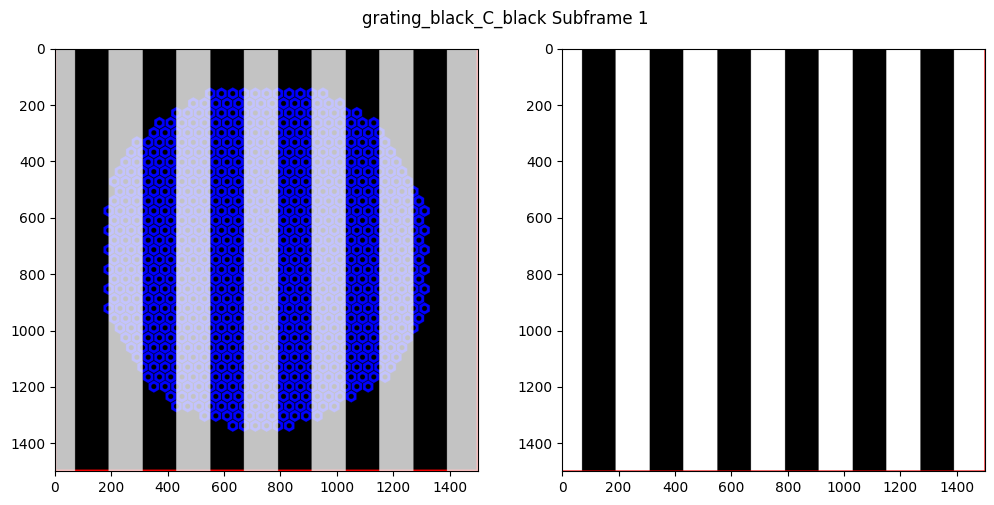

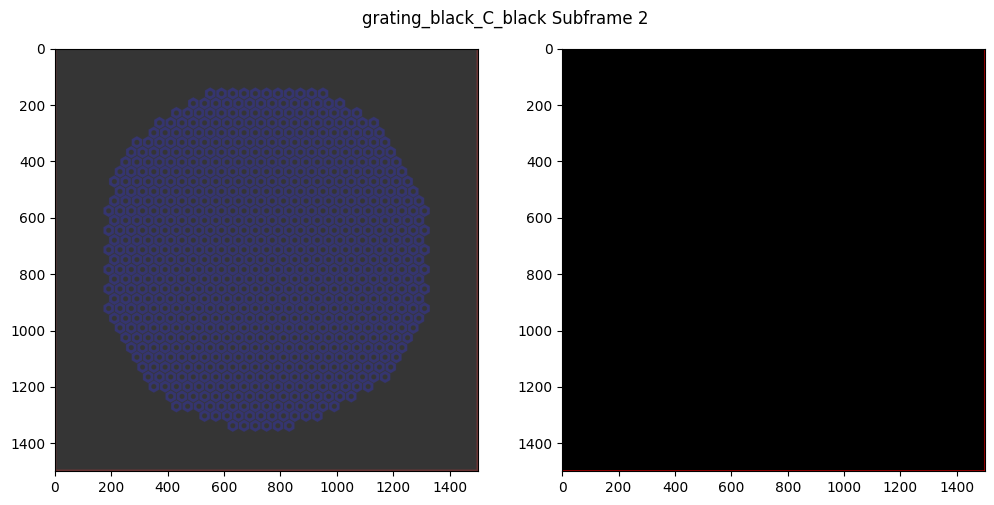

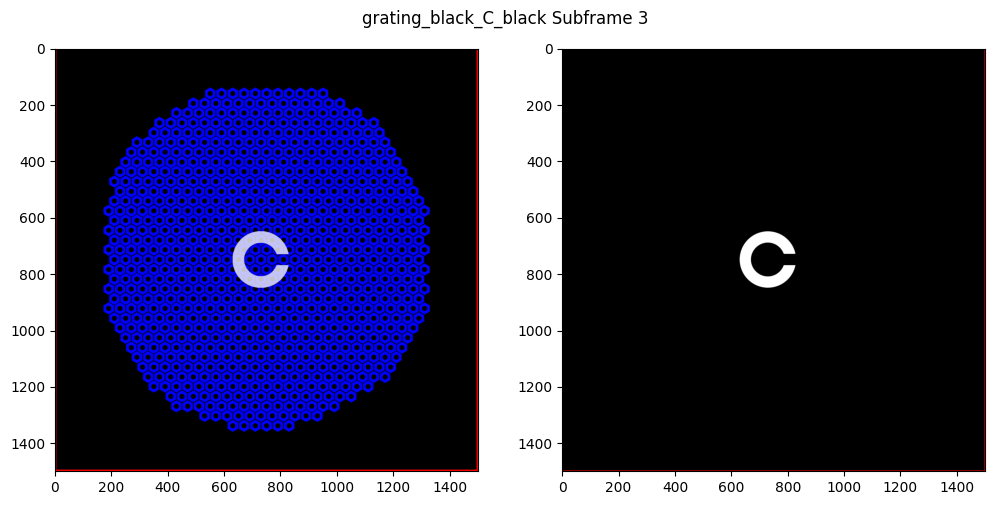

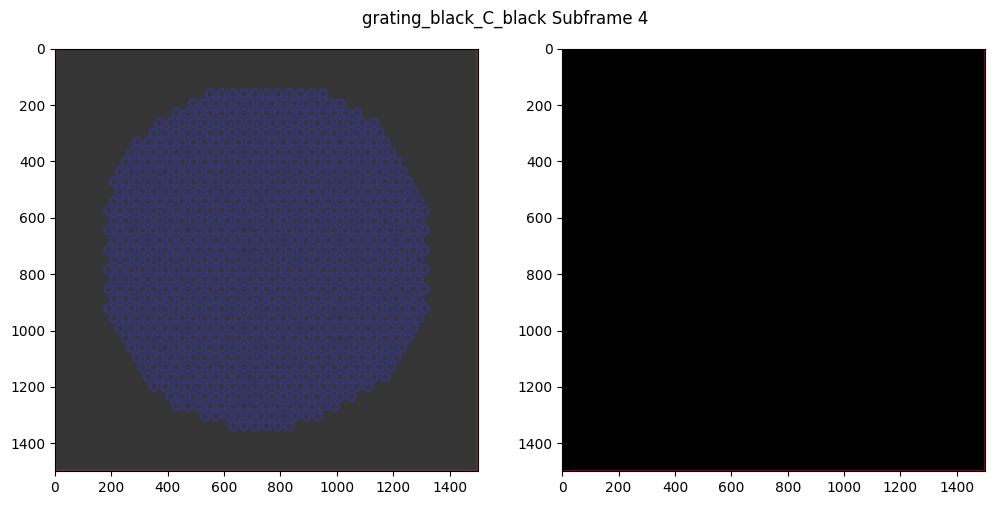

[2024-08-20 09:59:30] INFO       run_rpsim        Running Multiplexing Stage


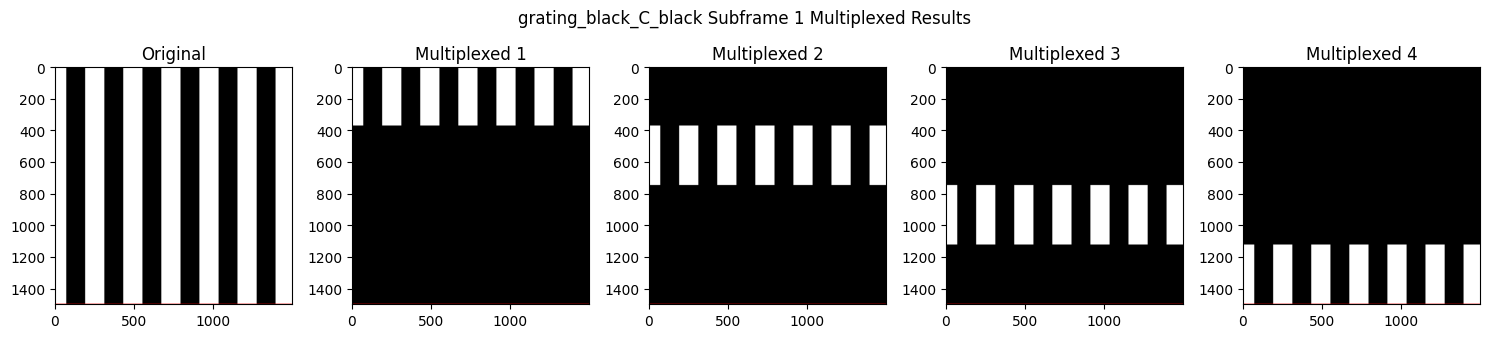

Is black frame


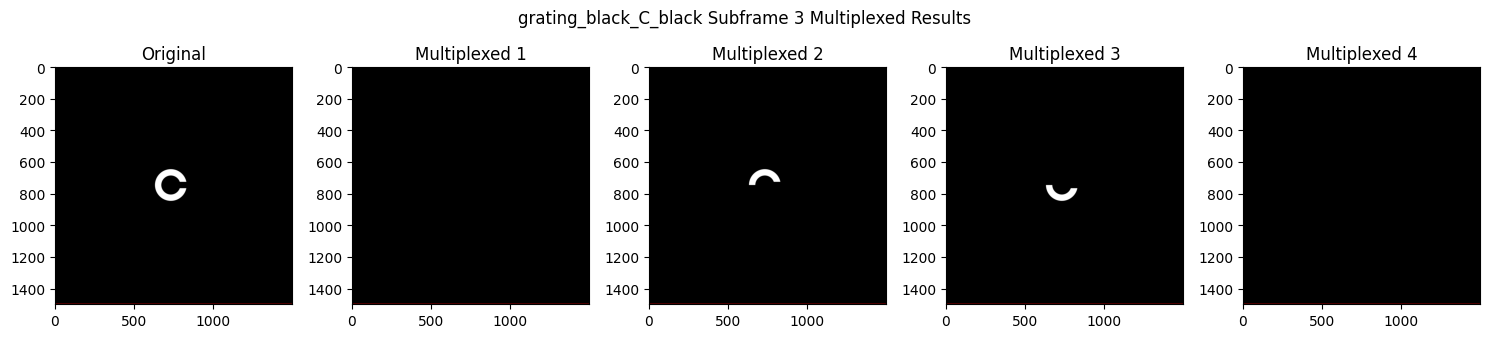

Is black frame
3.90625
3.90625
3.90625
3.90625


[2024-08-20 09:59:32] INFO       run_rpsim        Running Resistive_Mesh Stage
[2024-08-20 09:59:32] INFO       run_rpsim        Running Current_Sequence Stage


{'active_electrode_radius': 9, 'alg': 'horizontal', 'average_over_pulse_duration': False, 'cpu_to_use': 1, 'depth_values_in_um': None, 'font_path': None, 'frame_width': 750, 'generate_pattern': True, 'geometry': 'Flat_rat', 'ideality_factor': 1.5, 'initial_Vactive': 0.4, 'interpolation_resolution_ms': 0.001, 'Ipho_scaling': 1, 'Isat': 0.3, 'light_to_current_conversion_rate': 0.5, 'model': 'monopolar', 'multiplex': True, 'multiprocessing': False, 'nominal_temperature': 25, 'num_split': 4, 'number_of_diodes': 1, 'number_of_pixels': 821, 'on_diode_threshold_mV': 50, 'photosensitive_area': 867.8999183638593, 'photosensitive_area_edge_to_edge': 36, 'pixel_label_input_file': '/Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/user_files/user_input/image_sequence/pixel_label_PS40.pkl', 'pixel_size': 40, 'pixel_size_suffix': '', 'plot_potential_depth_um': 60, 'plot_time_window_end_ms': 209.8, 'plot_time_windwow_start_ms': 200.0, 'projection_sequences': <run_stages.pattern_generation_stage.Project

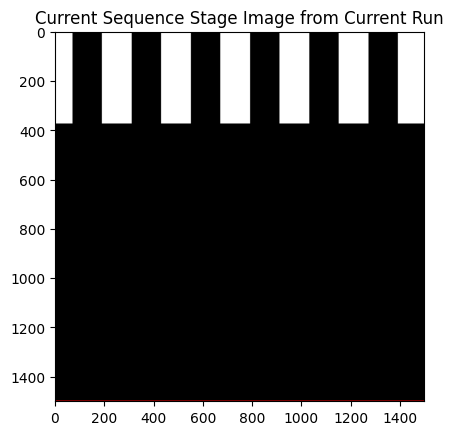

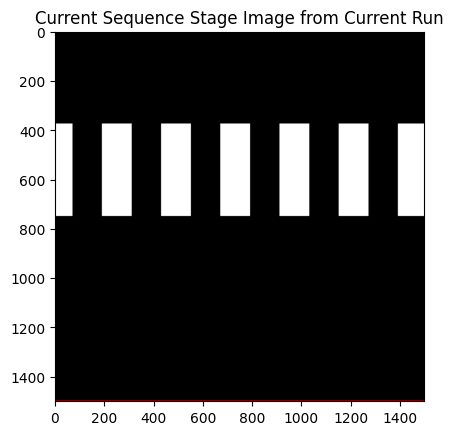

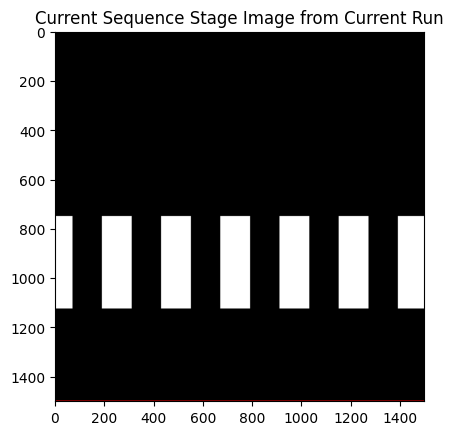

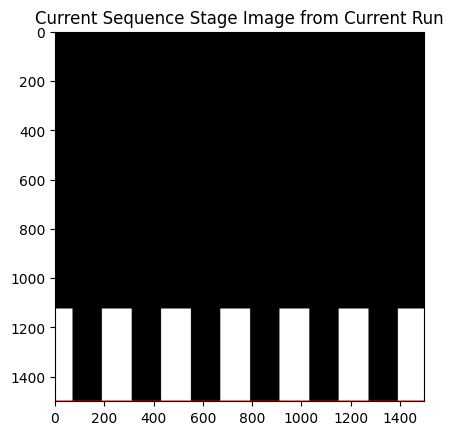

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


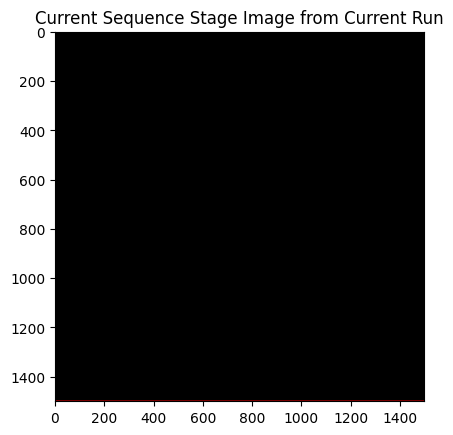

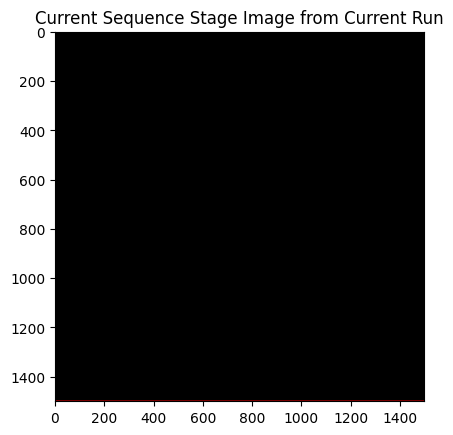

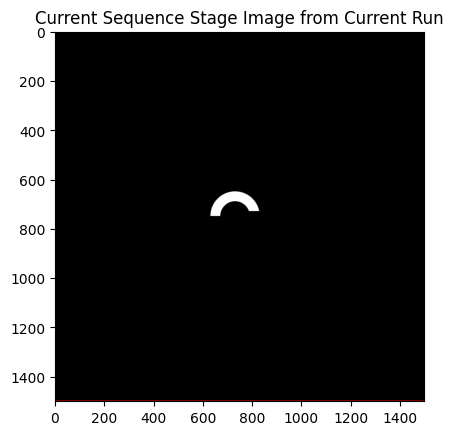

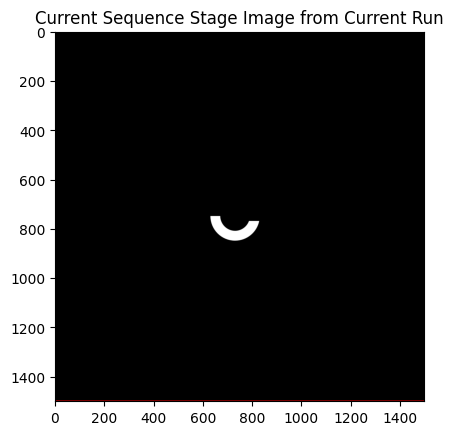

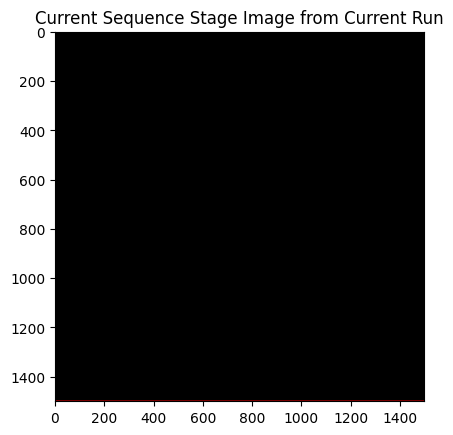

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


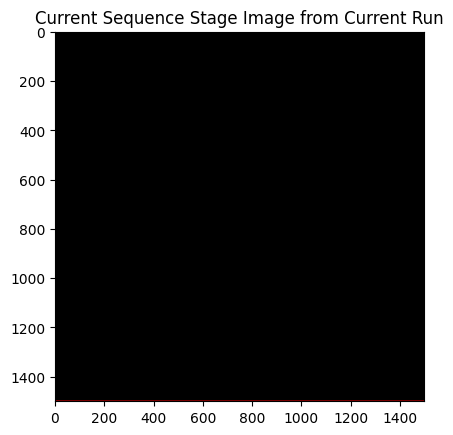

[2024-08-20 10:00:17] INFO       run_rpsim        Running Circuit Stage


821


[2024-08-20 10:00:25] INFO       run_rpsim        Running Simulation Stage
[2024-08-20 10:00:29] ERROR      run_rpsim        [Errno 2] No such file or directory: 'Xyce'
[2024-08-20 10:00:29] ERROR      run_rpsim        Whole error traceback:
 Traceback (most recent call last):
  File "/Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/run_stages/common_run_stage.py", line 60, in run
    self._stage_output = self.run_stage()
  File "/Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/run_stages/simulation_stage.py", line 43, in run_stage
    analysis = simulator.transient(step_time=video_sequence['time_step'] @ U.u_ms,
  File "/opt/miniconda3/lib/python3.9/site-packages/PySpice/Spice/Simulation.py", line 1214, in transient
    return self._run('transient', *args, **kwargs)
  File "/opt/miniconda3/lib/python3.9/site-packages/PySpice/Spice/Xyce/Simulation.py", line 66, in _run
    raw_file = self._xyce_server(spice_input=str(self))
  File "/opt/miniconda3/lib/python3.9/site-packages/PySpice/Spic

Simulation Stage execution failed with the following error: [Errno 2] No such file or directory: 'Xyce'


In [3]:
### EXECUTION
from RPSim import run_rpsim
# Stages name: "pattern_generation" - "resistive_mesh" - "current_sequence" - "circuit" - "simulation" - "post_process" - "plot_results"
run_stages = [ "pattern_generation", "multiplexing", "resistive_mesh", "current_sequence", "circuit", "simulation", 'post_process', 'plot_results']
run_rpsim(configuration=configuration, run_stages=run_stages)#, skip_stages="post_process")

## No pattern generation, start with multiplexing

[2024-08-20 10:00:54] INFO       run_rpsim        Staring a new run
[2024-08-20 10:00:54] INFO       run_rpsim        Output directory: /Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/user_files/user_output/10_00_54-2024_08_20
[2024-08-20 10:00:54] INFO       run_rpsim        Requested run stages: ['multiplexing', 'resistive_mesh', 'current_sequence', 'circuit', 'simulation', 'post_process', 'plot_results']
[2024-08-20 10:00:54] INFO       run_rpsim        Running the following configuration
====>User Inputs
+--------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------+
| Field                          | Value                                                                                                                                      |
+--------------------------------+----------------------------------------------------------------------------------------------------

Pattern generation skipped.. Using existing files at /Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/user_files/user_input/image_sequence/multiplex_test_case_1/seq_time.csv
Read image /Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/user_files/user_input/image_sequence/multiplex_test_case_1/grating_black_C_black/Subframe1.bmp


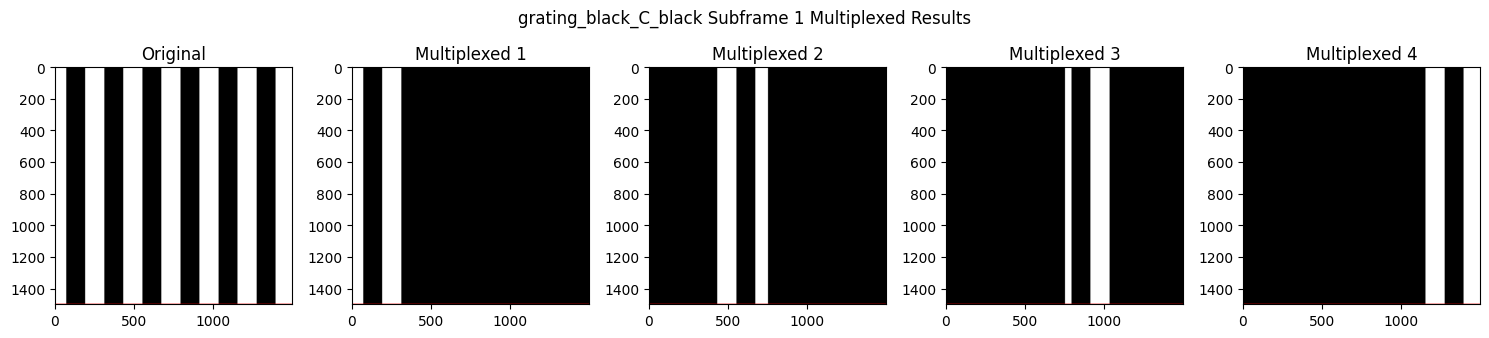

Read image /Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/user_files/user_input/image_sequence/multiplex_test_case_1/grating_black_C_black/Subframe2.bmp
Is black frame
Read image /Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/user_files/user_input/image_sequence/multiplex_test_case_1/grating_black_C_black/Subframe3.bmp


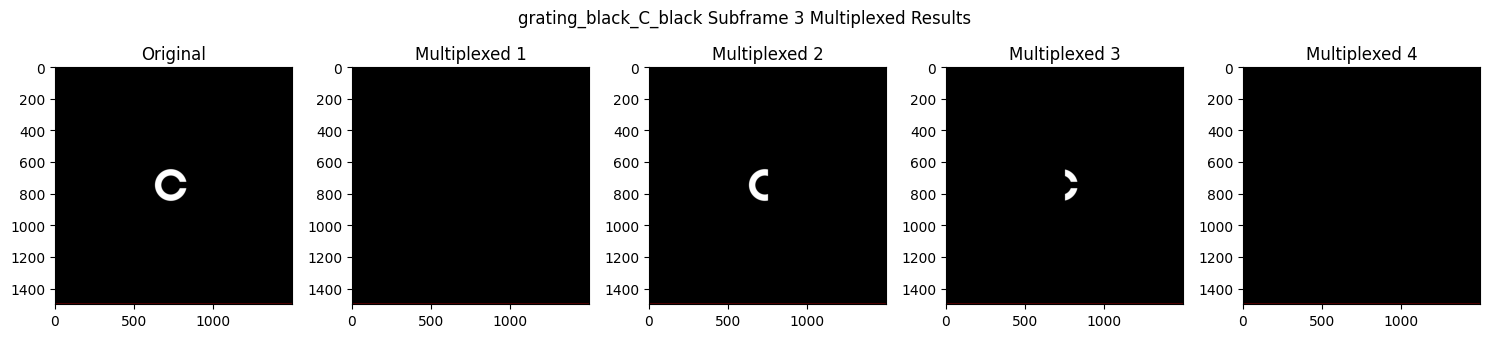

Read image /Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/user_files/user_input/image_sequence/multiplex_test_case_1/grating_black_C_black/Subframe4.bmp
Is black frame
3.90625
3.90625
3.90625
3.90625


[2024-08-20 10:00:56] INFO       run_rpsim        Running Resistive_Mesh Stage
[2024-08-20 10:00:57] INFO       run_rpsim        Running Current_Sequence Stage


Using multiplex list images
Length of frame data: 10
Content of frame data:  [0.9765625, 0.9765625, 0.9765625, 0.9765625, 3.90625, 0.9765625, 0.9765625, 0.9765625, 0.9765625, 3.90625]


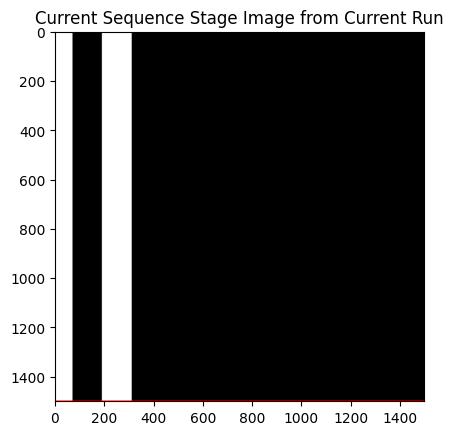

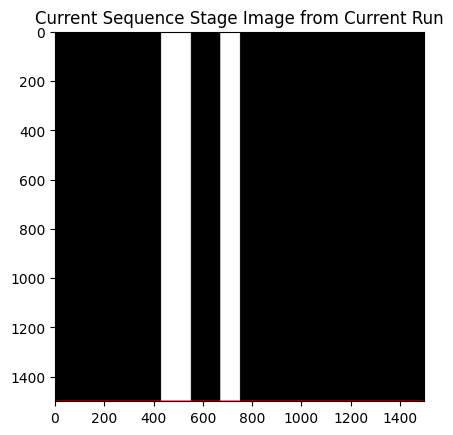

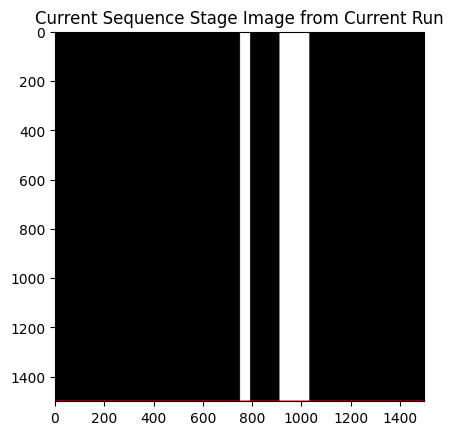

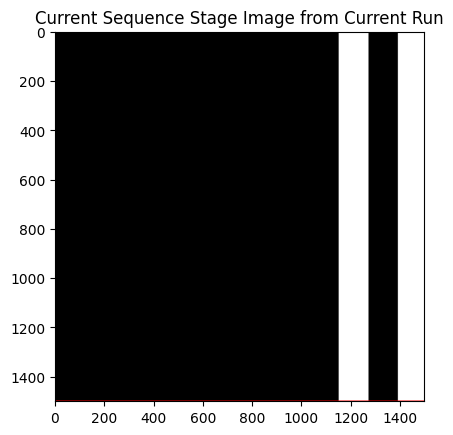

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


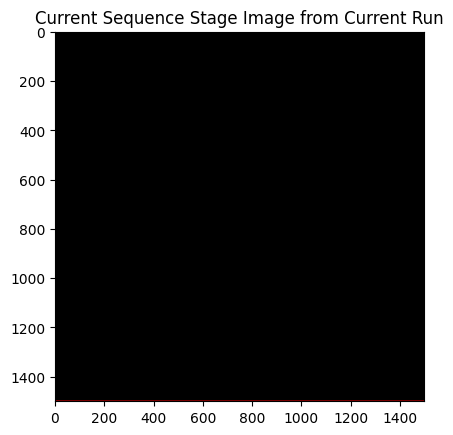

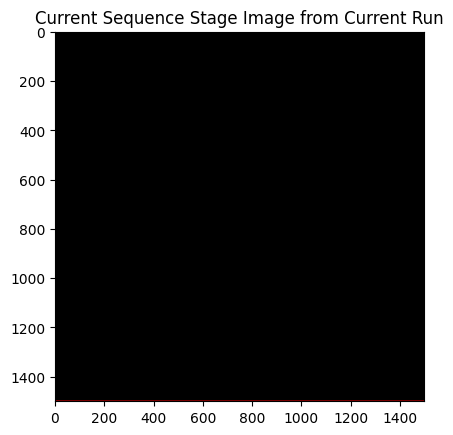

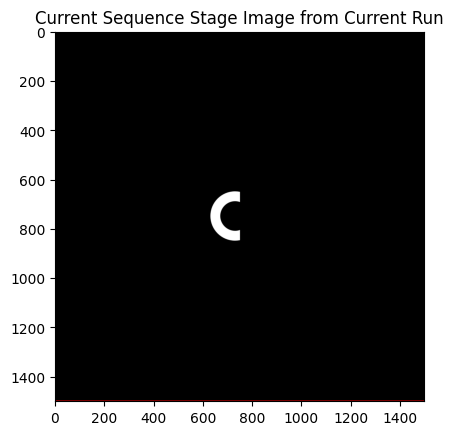

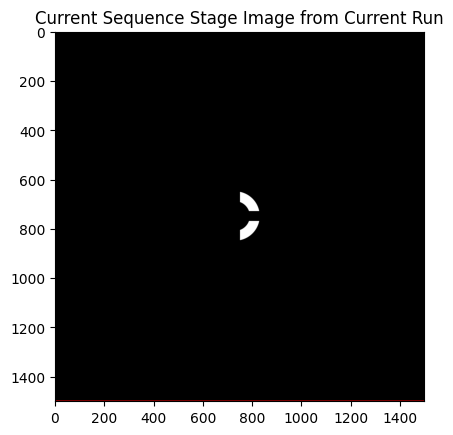

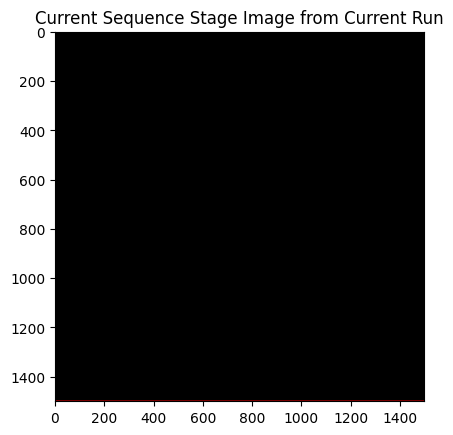

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


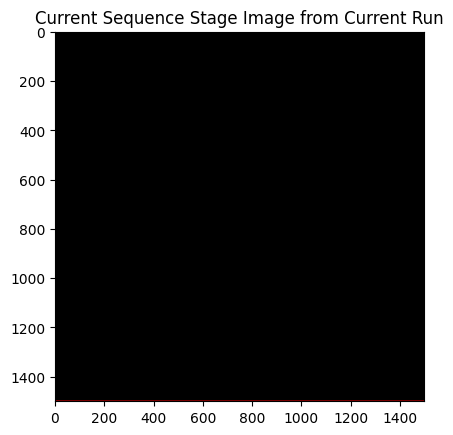

[2024-08-20 10:01:42] INFO       run_rpsim        Running Circuit Stage


821


[2024-08-20 10:01:50] INFO       run_rpsim        Running Simulation Stage
[2024-08-20 10:01:55] ERROR      run_rpsim        [Errno 2] No such file or directory: 'Xyce'
[2024-08-20 10:01:55] ERROR      run_rpsim        Whole error traceback:
 Traceback (most recent call last):
  File "/Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/run_stages/common_run_stage.py", line 60, in run
    self._stage_output = self.run_stage()
  File "/Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/run_stages/simulation_stage.py", line 43, in run_stage
    analysis = simulator.transient(step_time=video_sequence['time_step'] @ U.u_ms,
  File "/opt/miniconda3/lib/python3.9/site-packages/PySpice/Spice/Simulation.py", line 1214, in transient
    return self._run('transient', *args, **kwargs)
  File "/opt/miniconda3/lib/python3.9/site-packages/PySpice/Spice/Xyce/Simulation.py", line 66, in _run
    raw_file = self._xyce_server(spice_input=str(self))
  File "/opt/miniconda3/lib/python3.9/site-packages/PySpice/Spic

Simulation Stage execution failed with the following error: [Errno 2] No such file or directory: 'Xyce'


In [1]:
## MP40 RAT CONFIGURATION

generate_pattern = False

configuration = {}

# geometry-defined configuration
configuration["model"]                            = "monopolar"     # model geometry: monopolar or bipolar
configuration["pixel_size"]                       = 40           # pixel size
configuration["pixel_size_suffix"]                = ""         # If large format is required, use "-lg", else use ""
configuration["frame_width"]                      = 750       # implant radius in mm
configuration["geometry"]                         = "Flat_rat"  # geometry settings: HC/Pillar/Flat devices in
# pdish/rat/human
configuration["number_of_diodes"]                 = 1             # number of photo diodes per pixel
configuration["sirof_capacitance"]                = 6             # SIROF capacitance in mF/cm^2
configuration["photosensitive_area_edge_to_edge"] = 36           # edge-to-edge size of the photosensitive area
configuration["active_electrode_radius"]          = 9            # radius of the active electrode in um
configuration["light_to_current_conversion_rate"] = 0.5           # light to current conversion rate in A/W
configuration["photosensitive_area"]              = 867.8999183638593   # total photosensitive area in um^2. Assign
# "None" for
# auto calculation

# R matrix parameters
configuration["r_matrix_output_file"]             = f'R_{configuration["geometry"]}_PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}.pkl'
configuration["r_matrix_conductivity"]            = 1             # conductivity scaling factor of the electrolyte

# dynamic simulation configuration
configuration["Ipho_scaling"]                     = 1  # artificial scaling of photo current, useful for
                                                     # parametric sweep (e.g. S-D curve)
configuration["Isat"]                             = 0.3          # diode saturation current in pA
configuration["ideality_factor"]                  = 1.5          # ideality factor n of the diode
configuration["shunt_resistance"]                 = None         # shunt resistance in Ohm. Assign "None" if no shunt
configuration["initial_Vactive"]                  = 0.4          # Initial bias of the active electrode in V
configuration["temperature"]                      = 37
configuration["nominal_temperature"]              = 25
configuration["simulation_duration_sec"]          = 3             # simulation duration in seconds
configuration["simulation_resolution_ms"]         = None          # None defaults to Xyce inner value

# input paths
configuration["user_files_path"]                  = None          # If set to None, defaults to inner user_files directory
configuration["pixel_label_input_file"]           = f'image_sequence/pixel_label_PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}.pkl'

#### Projection sequences related ####

configuration["video_sequence_name"]              = "multiplex_test_case_1"

configuration["pattern_generation"]               = {"generate_pattern": generate_pattern}
add_projection_seq = any(generate_pattern) if type(generate_pattern) is list else generate_pattern
if add_projection_seq:
    tmp = \
        {
        "projection_sequences"              : list_projections,
        "font_path"                         : None, # If set to None for, defaults to optometrist font Sloan.otf
        "projection_sequences_stored_config" : None # Used for storing the config, but part of the skipped parameters
        }
    configuration["pattern_generation"].update(tmp)

# define input files for monopolar arrays
configuration["monopolar"] = \
    {
    "return_to_active_area_ratio": 5.7525,              # ratio between return area and total active area 
    "r_matrix_simp_ratio": 0.1,
    "r_matrix_input_file_px_pos": f'r_matrix/COMSOL_results/PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}_pos.csv',
    "r_matrix_input_file_active": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_active.csv',
    "r_matrix_input_file_EP_return_2D": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_EP_return_2D-whole.csv',
    "r_matrix_input_file_diagonal": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_EP_self.csv', # used for resistive mesh only
    "r_matrix_input_file_non_diagonal": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_EP_Rmat.csv' # used for resistive mesh only
    }

# define input files for bipolar arrays
bipolar_dict = \
    {
    "additional_edges": 142,                                     # bipolar only: edge segments of the return
    "r_matrix_simp_ratio": 0.1,
    "r_matrix_input_file_px_pos": f'r_matrix/COMSOL_results/PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}_pos.csv',
    "r_matrix_input_file_active": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_active.csv',
    "r_matrix_input_file_return": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_return.csv',
    "r_matrix_input_file_return_neighbor": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_return_neighbor.csv', # used for resistive mesh only
    }
if configuration["model"] == 'bipolar': # Special file existing only for the bipolar PS100 and PS75 configurations
        bipolar_dict["r_matrix_input_file_return_near"] = f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_return_near.csv'

configuration["bipolar"] = bipolar_dict

# post-process parameters
configuration["post_process"] = \
    {
    "pulse_start_time_in_ms": 2500, #(1/frequency)*1e3, # TODO this could be automated, or made smaller
    "pulse_duration_in_ms": 8,
    # Related to the time dynamics analyzis
    "average_over_pulse_duration": False,
    "pulse_extra_ms": 0,
    "time_averaging_resolution_ms": 1,
    "interpolation_resolution_ms": 1e-3,
    # For improving computations speed, warning it may crash for sume configurations!
    "multiprocessing": False,
    "cpu_to_use": None, # If set to None, automatically uses 2/3 of the cpu available
    # Related to spatial analyzis 
    "depth_values_in_um": None, #[[0, 45, 77, 86, 109, 142]], # if None, defaults to all available in model
    "on_diode_threshold_mV": 50
    }

configuration["plot_results"] = \
    {
    "plot_time_windwow_start_ms": 200.0, # If set to None, selects the post proces stage values
    "plot_time_window_end_ms": 209.8,
    "plot_potential_depth_um": 60
    }

configuration['multiplexing'] = {'multiplex': True, 'num_split': 4, 'alg': 'vertical'} 

### EXECUTION
from RPSim import run_rpsim
# Stages name: "pattern_generation" - "resistive_mesh" - "current_sequence" - "circuit" - "simulation" - "post_process" - "plot_results"
run_stages = ["multiplexing", "resistive_mesh", "current_sequence", "circuit", "simulation", 'post_process', 'plot_results']
run_rpsim(configuration=configuration, run_stages=run_stages)#, skip_stages="post_process")

## Skipped both pattern_gen and multiplexing, load existing image from folder
### Case 1: use multiplexed file inside

[2024-08-20 10:02:12] INFO       run_rpsim        Staring a new run
[2024-08-20 10:02:12] INFO       run_rpsim        Output directory: /Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/user_files/user_output/10_02_12-2024_08_20
[2024-08-20 10:02:12] INFO       run_rpsim        Requested run stages: ['resistive_mesh', 'current_sequence', 'circuit', 'simulation', 'post_process', 'plot_results']
[2024-08-20 10:02:12] INFO       run_rpsim        Running the following configuration
====>User Inputs
+--------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------+
| Field                          | Value                                                                                                                                      |
+--------------------------------+--------------------------------------------------------------------------------------------------------------------

Using seq_time_multiplexed.csv
Length of frame data: 10
Content of frame data:  [0.9765625, 0.9765625, 0.9765625, 0.9765625, 3.90625, 0.9765625, 0.9765625, 0.9765625, 0.9765625, 3.90625]


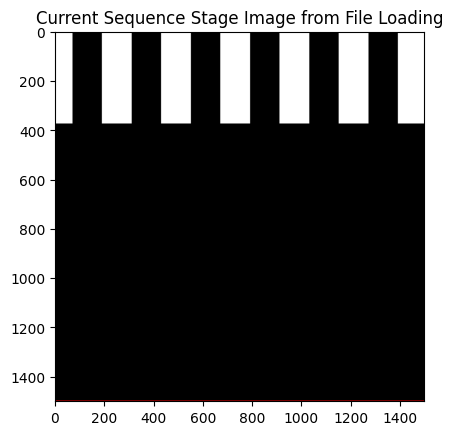

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


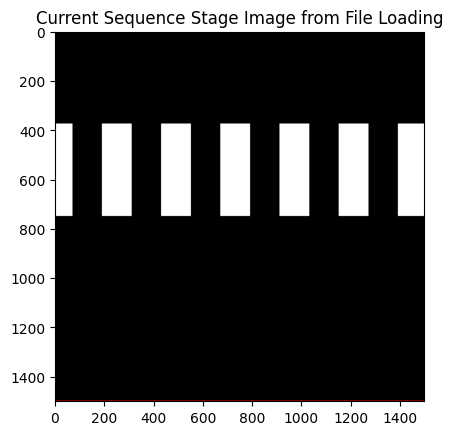

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


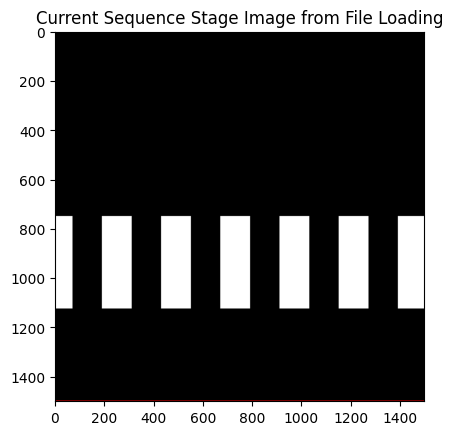

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


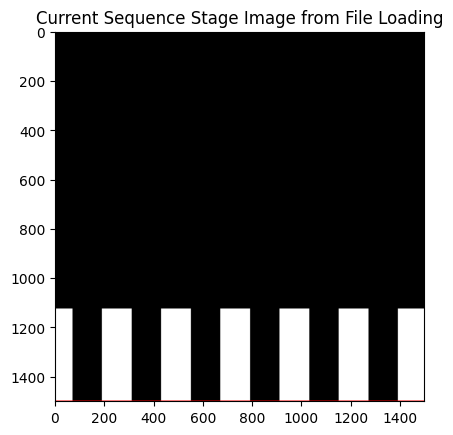

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


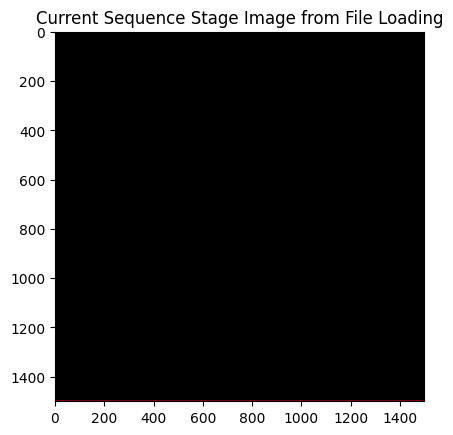

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


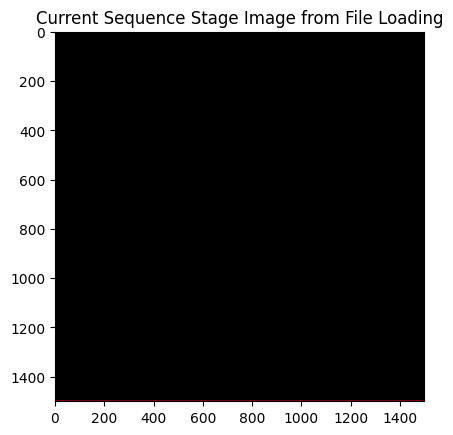

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


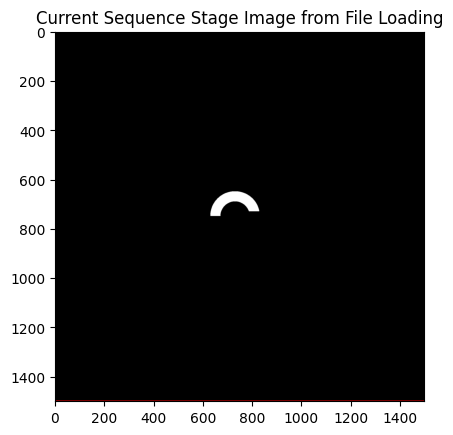

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


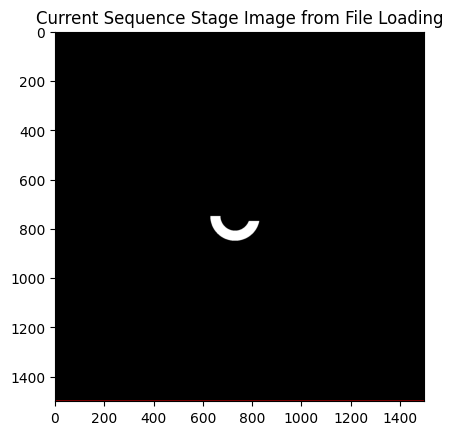

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


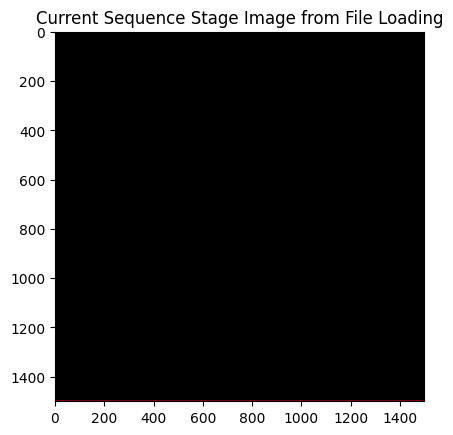

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


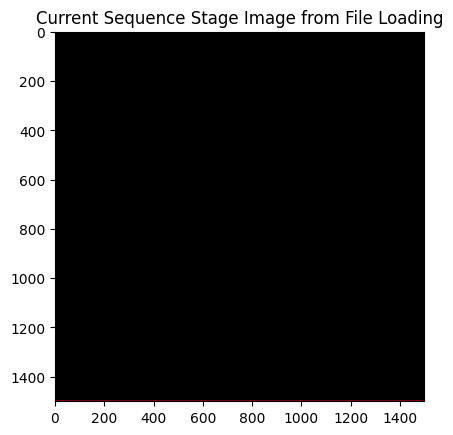

[2024-08-20 10:02:58] INFO       run_rpsim        Running Circuit Stage


821


[2024-08-20 10:03:06] INFO       run_rpsim        Running Simulation Stage
[2024-08-20 10:03:11] ERROR      run_rpsim        [Errno 2] No such file or directory: 'Xyce'
[2024-08-20 10:03:11] ERROR      run_rpsim        Whole error traceback:
 Traceback (most recent call last):
  File "/Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/run_stages/common_run_stage.py", line 60, in run
    self._stage_output = self.run_stage()
  File "/Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/run_stages/simulation_stage.py", line 43, in run_stage
    analysis = simulator.transient(step_time=video_sequence['time_step'] @ U.u_ms,
  File "/opt/miniconda3/lib/python3.9/site-packages/PySpice/Spice/Simulation.py", line 1214, in transient
    return self._run('transient', *args, **kwargs)
  File "/opt/miniconda3/lib/python3.9/site-packages/PySpice/Spice/Xyce/Simulation.py", line 66, in _run
    raw_file = self._xyce_server(spice_input=str(self))
  File "/opt/miniconda3/lib/python3.9/site-packages/PySpice/Spic

Simulation Stage execution failed with the following error: [Errno 2] No such file or directory: 'Xyce'


In [1]:
## MP40 RAT CONFIGURATION

generate_pattern = False
use_multiplex = True # Have to specify this!

configuration = {}

# geometry-defined configuration
configuration["model"]                            = "monopolar"     # model geometry: monopolar or bipolar
configuration["pixel_size"]                       = 40           # pixel size
configuration["pixel_size_suffix"]                = ""         # If large format is required, use "-lg", else use ""
configuration["frame_width"]                      = 750       # implant radius in mm
configuration["geometry"]                         = "Flat_rat"  # geometry settings: HC/Pillar/Flat devices in
# pdish/rat/human
configuration["number_of_diodes"]                 = 1             # number of photo diodes per pixel
configuration["sirof_capacitance"]                = 6             # SIROF capacitance in mF/cm^2
configuration["photosensitive_area_edge_to_edge"] = 36           # edge-to-edge size of the photosensitive area
configuration["active_electrode_radius"]          = 9            # radius of the active electrode in um
configuration["light_to_current_conversion_rate"] = 0.5           # light to current conversion rate in A/W
configuration["photosensitive_area"]              = 867.8999183638593   # total photosensitive area in um^2. Assign
# "None" for
# auto calculation

# R matrix parameters
configuration["r_matrix_output_file"]             = f'R_{configuration["geometry"]}_PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}.pkl'
configuration["r_matrix_conductivity"]            = 1             # conductivity scaling factor of the electrolyte

# dynamic simulation configuration
configuration["Ipho_scaling"]                     = 1  # artificial scaling of photo current, useful for
                                                     # parametric sweep (e.g. S-D curve)
configuration["Isat"]                             = 0.3          # diode saturation current in pA
configuration["ideality_factor"]                  = 1.5          # ideality factor n of the diode
configuration["shunt_resistance"]                 = None         # shunt resistance in Ohm. Assign "None" if no shunt
configuration["initial_Vactive"]                  = 0.4          # Initial bias of the active electrode in V
configuration["temperature"]                      = 37
configuration["nominal_temperature"]              = 25
configuration["simulation_duration_sec"]          = 3             # simulation duration in seconds
configuration["simulation_resolution_ms"]         = None          # None defaults to Xyce inner value

# input paths
configuration["user_files_path"]                  = None          # If set to None, defaults to inner user_files directory
configuration["pixel_label_input_file"]           = f'image_sequence/pixel_label_PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}.pkl'

#### Projection sequences related ####

configuration["video_sequence_name"]              = "multiplex_test_case_1_w_multiplex"

configuration["pattern_generation"]               = {"generate_pattern": generate_pattern,
                                                     "use_multiplex": use_multiplex,
                                                     }
add_projection_seq = any(generate_pattern) if type(generate_pattern) is list else generate_pattern
if add_projection_seq:
    tmp = \
        {
        "projection_sequences"              : list_projections,
        "font_path"                         : None, # If set to None for, defaults to optometrist font Sloan.otf
        "projection_sequences_stored_config" : None # Used for storing the config, but part of the skipped parameters
        }
    configuration["pattern_generation"].update(tmp)

# define input files for monopolar arrays
configuration["monopolar"] = \
    {
    "return_to_active_area_ratio": 5.7525,              # ratio between return area and total active area 
    "r_matrix_simp_ratio": 0.1,
    "r_matrix_input_file_px_pos": f'r_matrix/COMSOL_results/PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}_pos.csv',
    "r_matrix_input_file_active": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_active.csv',
    "r_matrix_input_file_EP_return_2D": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_EP_return_2D-whole.csv',
    "r_matrix_input_file_diagonal": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_EP_self.csv', # used for resistive mesh only
    "r_matrix_input_file_non_diagonal": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_EP_Rmat.csv' # used for resistive mesh only
    }

# define input files for bipolar arrays
bipolar_dict = \
    {
    "additional_edges": 142,                                     # bipolar only: edge segments of the return
    "r_matrix_simp_ratio": 0.1,
    "r_matrix_input_file_px_pos": f'r_matrix/COMSOL_results/PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}_pos.csv',
    "r_matrix_input_file_active": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_active.csv',
    "r_matrix_input_file_return": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_return.csv',
    "r_matrix_input_file_return_neighbor": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_return_neighbor.csv', # used for resistive mesh only
    }
if configuration["model"] == 'bipolar': # Special file existing only for the bipolar PS100 and PS75 configurations
        bipolar_dict["r_matrix_input_file_return_near"] = f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_return_near.csv'

configuration["bipolar"] = bipolar_dict

# post-process parameters
configuration["post_process"] = \
    {
    "pulse_start_time_in_ms": 2500, #(1/frequency)*1e3, # TODO this could be automated, or made smaller
    "pulse_duration_in_ms": 8,
    # Related to the time dynamics analyzis
    "average_over_pulse_duration": False,
    "pulse_extra_ms": 0,
    "time_averaging_resolution_ms": 1,
    "interpolation_resolution_ms": 1e-3,
    # For improving computations speed, warning it may crash for sume configurations!
    "multiprocessing": False,
    "cpu_to_use": None, # If set to None, automatically uses 2/3 of the cpu available
    # Related to spatial analyzis 
    "depth_values_in_um": None, #[[0, 45, 77, 86, 109, 142]], # if None, defaults to all available in model
    "on_diode_threshold_mV": 50
    }

configuration["plot_results"] = \
    {
    "plot_time_windwow_start_ms": 200.0, # If set to None, selects the post proces stage values
    "plot_time_window_end_ms": 209.8,
    "plot_potential_depth_um": 60
    }

# configuration['use_multiplex_input'] = True

### EXECUTION
from RPSim import run_rpsim
# Stages name: "pattern_generation" - "resistive_mesh" - "current_sequence" - "circuit" - "simulation" - "post_process" - "plot_results"
run_stages = ["resistive_mesh", "current_sequence", "circuit", "simulation", 'post_process', 'plot_results']
run_rpsim(configuration=configuration, run_stages=run_stages)#, skip_stages="post_process")

### Case 2: use non-multiplexed file inside (in case this directory contains both multiplexed output and non-multiplexed output)

[2024-08-20 10:06:09] INFO       run_rpsim        Staring a new run
[2024-08-20 10:06:09] INFO       run_rpsim        Output directory: /Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/user_files/user_output/10_06_09-2024_08_20
[2024-08-20 10:06:09] INFO       run_rpsim        Requested run stages: ['resistive_mesh', 'current_sequence', 'circuit', 'simulation', 'post_process', 'plot_results']
[2024-08-20 10:06:09] INFO       run_rpsim        Running the following configuration
====>User Inputs
+--------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------+
| Field                          | Value                                                                                                                                      |
+--------------------------------+--------------------------------------------------------------------------------------------------------------------

Length of frame data: 4
Content of frame data:  [3.90625, 3.90625, 3.90625, 3.90625]


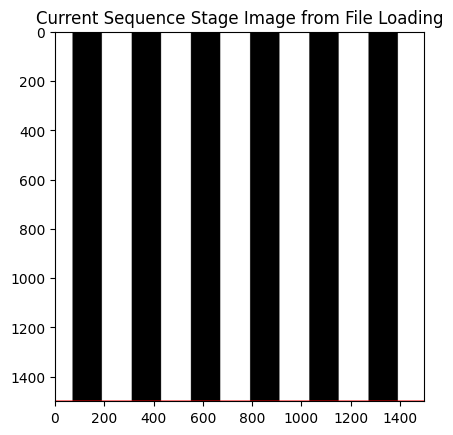

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


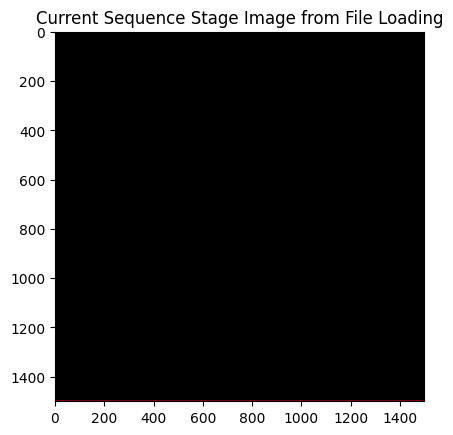

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


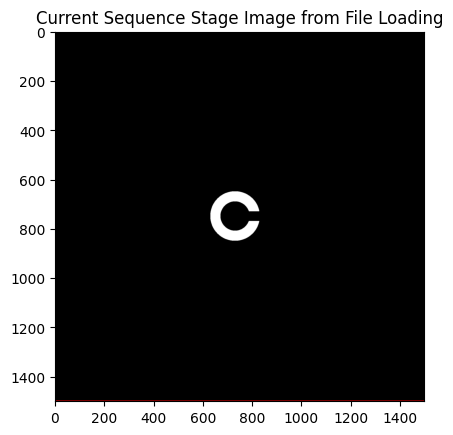

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


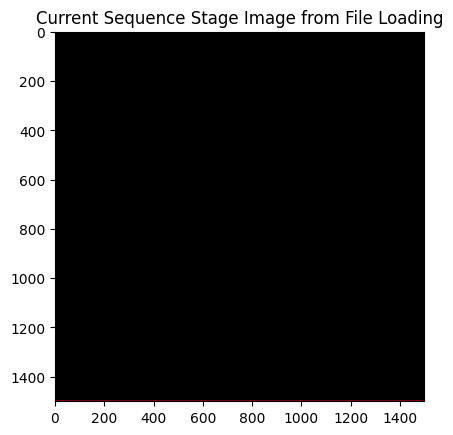

[2024-08-20 10:06:29] INFO       run_rpsim        Running Circuit Stage


821


[2024-08-20 10:06:38] INFO       run_rpsim        Running Simulation Stage
[2024-08-20 10:06:42] ERROR      run_rpsim        [Errno 2] No such file or directory: 'Xyce'
[2024-08-20 10:06:42] ERROR      run_rpsim        Whole error traceback:
 Traceback (most recent call last):
  File "/Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/run_stages/common_run_stage.py", line 60, in run
    self._stage_output = self.run_stage()
  File "/Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/run_stages/simulation_stage.py", line 43, in run_stage
    analysis = simulator.transient(step_time=video_sequence['time_step'] @ U.u_ms,
  File "/opt/miniconda3/lib/python3.9/site-packages/PySpice/Spice/Simulation.py", line 1214, in transient
    return self._run('transient', *args, **kwargs)
  File "/opt/miniconda3/lib/python3.9/site-packages/PySpice/Spice/Xyce/Simulation.py", line 66, in _run
    raw_file = self._xyce_server(spice_input=str(self))
  File "/opt/miniconda3/lib/python3.9/site-packages/PySpice/Spic

Simulation Stage execution failed with the following error: [Errno 2] No such file or directory: 'Xyce'


In [1]:
## MP40 RAT CONFIGURATION

generate_pattern = False
use_multiplex = False # Have to specify this!

configuration = {}

# geometry-defined configuration
configuration["model"]                            = "monopolar"     # model geometry: monopolar or bipolar
configuration["pixel_size"]                       = 40           # pixel size
configuration["pixel_size_suffix"]                = ""         # If large format is required, use "-lg", else use ""
configuration["frame_width"]                      = 750       # implant radius in mm
configuration["geometry"]                         = "Flat_rat"  # geometry settings: HC/Pillar/Flat devices in
# pdish/rat/human
configuration["number_of_diodes"]                 = 1             # number of photo diodes per pixel
configuration["sirof_capacitance"]                = 6             # SIROF capacitance in mF/cm^2
configuration["photosensitive_area_edge_to_edge"] = 36           # edge-to-edge size of the photosensitive area
configuration["active_electrode_radius"]          = 9            # radius of the active electrode in um
configuration["light_to_current_conversion_rate"] = 0.5           # light to current conversion rate in A/W
configuration["photosensitive_area"]              = 867.8999183638593   # total photosensitive area in um^2. Assign
# "None" for
# auto calculation

# R matrix parameters
configuration["r_matrix_output_file"]             = f'R_{configuration["geometry"]}_PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}.pkl'
configuration["r_matrix_conductivity"]            = 1             # conductivity scaling factor of the electrolyte

# dynamic simulation configuration
configuration["Ipho_scaling"]                     = 1  # artificial scaling of photo current, useful for
                                                     # parametric sweep (e.g. S-D curve)
configuration["Isat"]                             = 0.3          # diode saturation current in pA
configuration["ideality_factor"]                  = 1.5          # ideality factor n of the diode
configuration["shunt_resistance"]                 = None         # shunt resistance in Ohm. Assign "None" if no shunt
configuration["initial_Vactive"]                  = 0.4          # Initial bias of the active electrode in V
configuration["temperature"]                      = 37
configuration["nominal_temperature"]              = 25
configuration["simulation_duration_sec"]          = 3             # simulation duration in seconds
configuration["simulation_resolution_ms"]         = None          # None defaults to Xyce inner value

# input paths
configuration["user_files_path"]                  = None          # If set to None, defaults to inner user_files directory
configuration["pixel_label_input_file"]           = f'image_sequence/pixel_label_PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}.pkl'

#### Projection sequences related ####

configuration["video_sequence_name"]              = "multiplex_test_case_1_w_multiplex" # TODO: hardcoded

configuration["pattern_generation"]               = {"generate_pattern": generate_pattern,
                                                     "use_multiplex": use_multiplex,
                                                     }
add_projection_seq = any(generate_pattern) if type(generate_pattern) is list else generate_pattern
if add_projection_seq:
    tmp = \
        {
        "projection_sequences"              : list_projections,
        "font_path"                         : None, # If set to None for, defaults to optometrist font Sloan.otf
        "projection_sequences_stored_config" : None # Used for storing the config, but part of the skipped parameters
        }
    configuration["pattern_generation"].update(tmp)

# define input files for monopolar arrays
configuration["monopolar"] = \
    {
    "return_to_active_area_ratio": 5.7525,              # ratio between return area and total active area 
    "r_matrix_simp_ratio": 0.1,
    "r_matrix_input_file_px_pos": f'r_matrix/COMSOL_results/PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}_pos.csv',
    "r_matrix_input_file_active": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_active.csv',
    "r_matrix_input_file_EP_return_2D": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_EP_return_2D-whole.csv',
    "r_matrix_input_file_diagonal": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_EP_self.csv', # used for resistive mesh only
    "r_matrix_input_file_non_diagonal": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_EP_Rmat.csv' # used for resistive mesh only
    }

# define input files for bipolar arrays
bipolar_dict = \
    {
    "additional_edges": 142,                                     # bipolar only: edge segments of the return
    "r_matrix_simp_ratio": 0.1,
    "r_matrix_input_file_px_pos": f'r_matrix/COMSOL_results/PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}_pos.csv',
    "r_matrix_input_file_active": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_active.csv',
    "r_matrix_input_file_return": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_return.csv',
    "r_matrix_input_file_return_neighbor": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_return_neighbor.csv', # used for resistive mesh only
    }
if configuration["model"] == 'bipolar': # Special file existing only for the bipolar PS100 and PS75 configurations
        bipolar_dict["r_matrix_input_file_return_near"] = f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_return_near.csv'

configuration["bipolar"] = bipolar_dict

# post-process parameters
configuration["post_process"] = \
    {
    "pulse_start_time_in_ms": 2500, #(1/frequency)*1e3, # TODO this could be automated, or made smaller
    "pulse_duration_in_ms": 8,
    # Related to the time dynamics analyzis
    "average_over_pulse_duration": False,
    "pulse_extra_ms": 0,
    "time_averaging_resolution_ms": 1,
    "interpolation_resolution_ms": 1e-3,
    # For improving computations speed, warning it may crash for sume configurations!
    "multiprocessing": False,
    "cpu_to_use": None, # If set to None, automatically uses 2/3 of the cpu available
    # Related to spatial analyzis 
    "depth_values_in_um": None, #[[0, 45, 77, 86, 109, 142]], # if None, defaults to all available in model
    "on_diode_threshold_mV": 50
    }

configuration["plot_results"] = \
    {
    "plot_time_windwow_start_ms": 200.0, # If set to None, selects the post proces stage values
    "plot_time_window_end_ms": 209.8,
    "plot_potential_depth_um": 60
    }

# configuration['use_multiplex_input'] = True

### EXECUTION
from RPSim import run_rpsim
# Stages name: "pattern_generation" - "resistive_mesh" - "current_sequence" - "circuit" - "simulation" - "post_process" - "plot_results"
run_stages = ["resistive_mesh", "current_sequence", "circuit", "simulation", 'post_process', 'plot_results']
run_rpsim(configuration=configuration, run_stages=run_stages)#, skip_stages="post_process")

## Pattern generation without multiplex

[2024-08-20 10:06:53] INFO       run_rpsim        Staring a new run
[2024-08-20 10:06:53] INFO       run_rpsim        Output directory: /Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/user_files/user_output/10_06_53-2024_08_20
[2024-08-20 10:06:53] INFO       run_rpsim        Requested run stages: ['pattern_generation', 'resistive_mesh', 'current_sequence', 'circuit', 'simulation', 'post_process', 'plot_results']
[2024-08-20 10:06:54] INFO       run_rpsim        Running the following configuration
====>User Inputs
+--------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------+
| Field                          | Value                                                                                                                                      |
+--------------------------------+----------------------------------------------------------------------------------------------

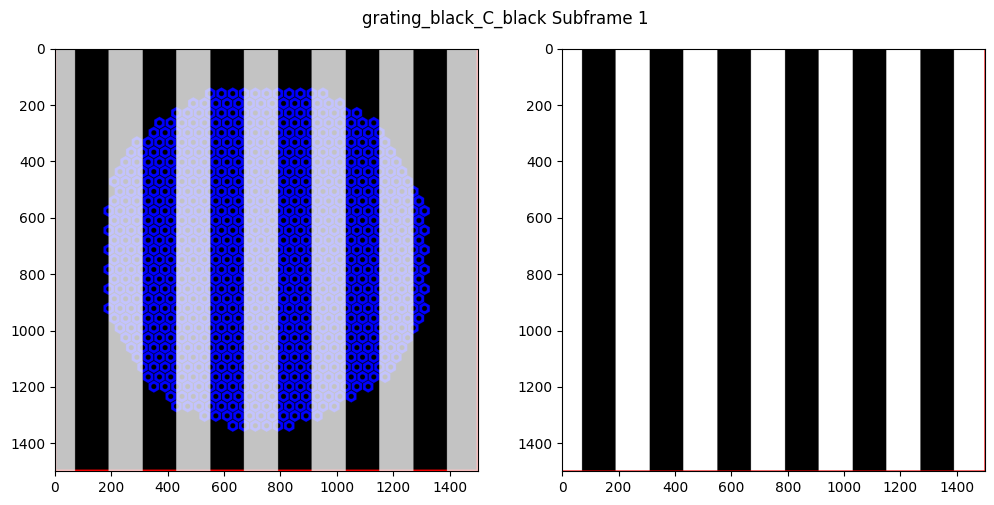

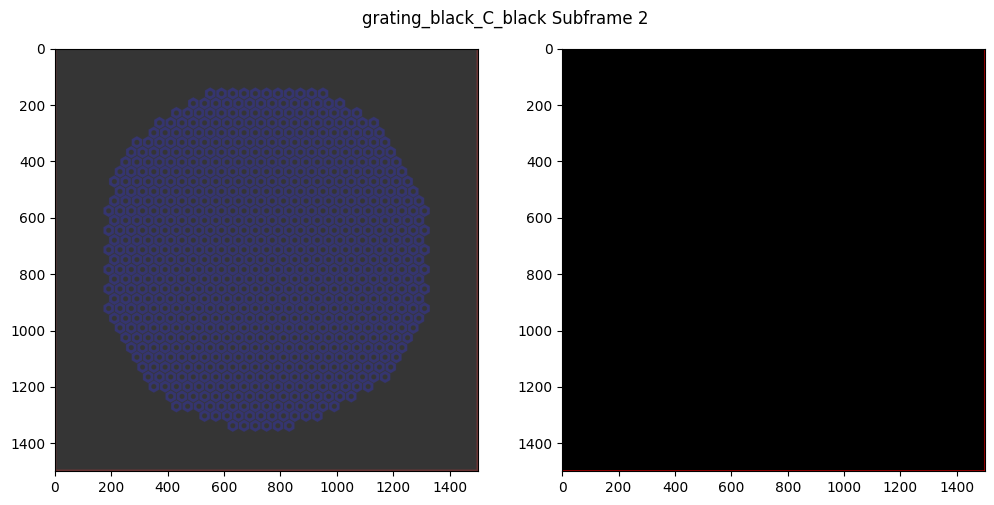

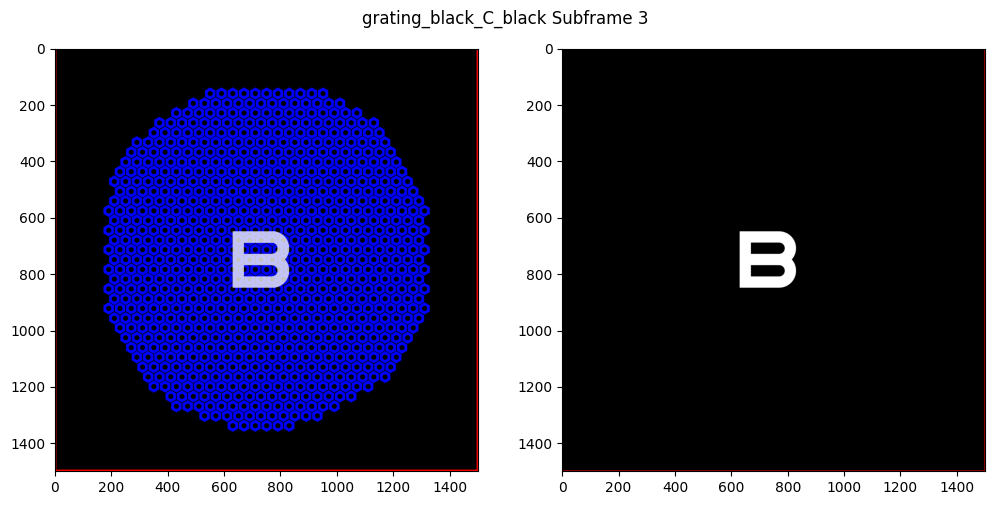

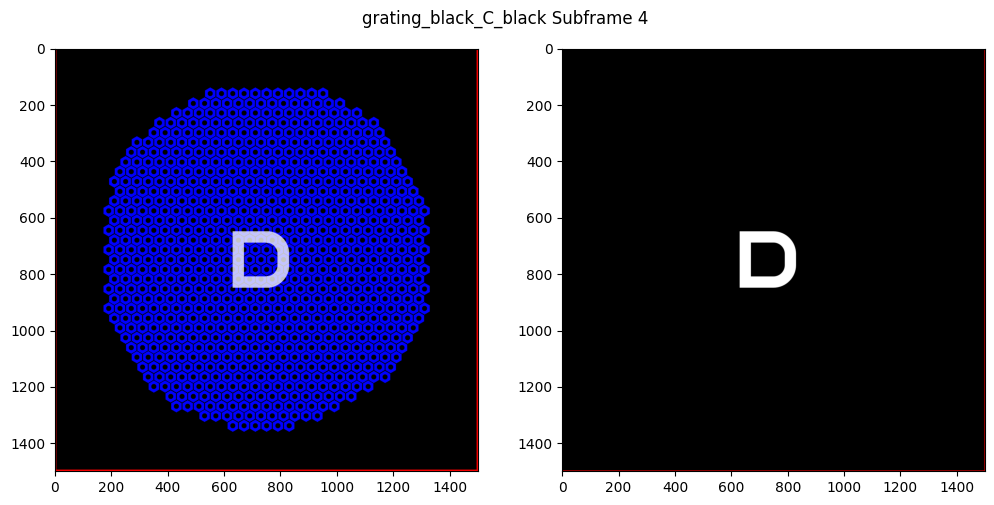

[2024-08-20 10:06:57] INFO       run_rpsim        Running Resistive_Mesh Stage
[2024-08-20 10:06:57] INFO       run_rpsim        Running Current_Sequence Stage
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Length of frame data: 4
Content of frame data:  [3.90625, 3.90625, 3.90625, 3.90625]


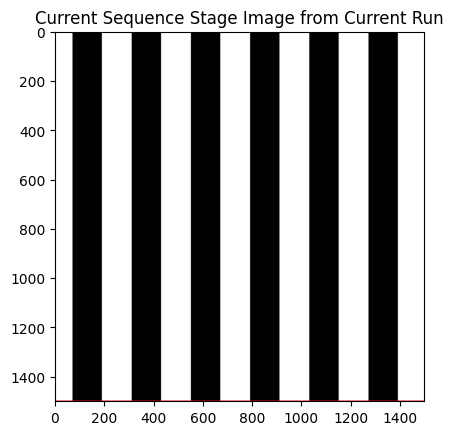

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


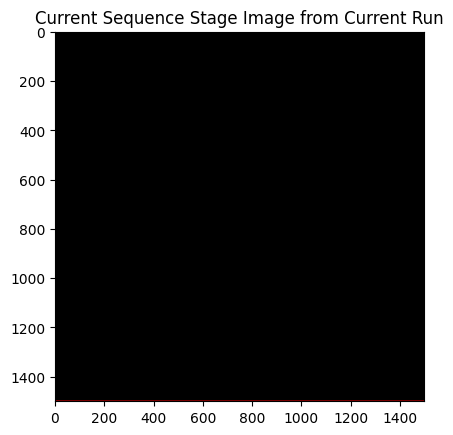

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


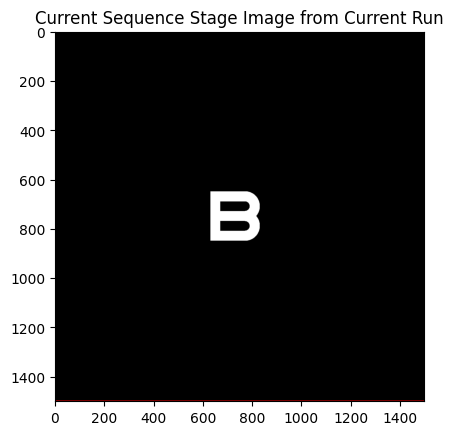

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


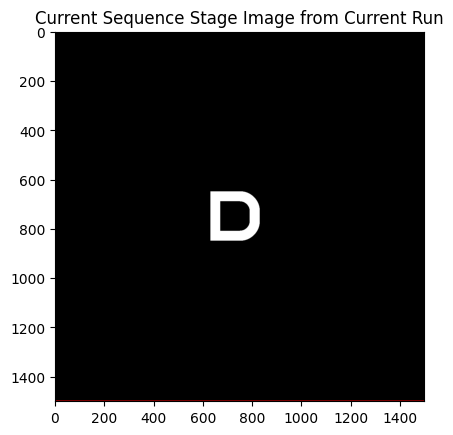

[2024-08-20 10:07:16] INFO       run_rpsim        Running Circuit Stage


821


[2024-08-20 10:07:24] INFO       run_rpsim        Running Simulation Stage
[2024-08-20 10:07:28] ERROR      run_rpsim        [Errno 2] No such file or directory: 'Xyce'
[2024-08-20 10:07:28] ERROR      run_rpsim        Whole error traceback:
 Traceback (most recent call last):
  File "/Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/run_stages/common_run_stage.py", line 60, in run
    self._stage_output = self.run_stage()
  File "/Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/run_stages/simulation_stage.py", line 43, in run_stage
    analysis = simulator.transient(step_time=video_sequence['time_step'] @ U.u_ms,
  File "/opt/miniconda3/lib/python3.9/site-packages/PySpice/Spice/Simulation.py", line 1214, in transient
    return self._run('transient', *args, **kwargs)
  File "/opt/miniconda3/lib/python3.9/site-packages/PySpice/Spice/Xyce/Simulation.py", line 66, in _run
    raw_file = self._xyce_server(spice_input=str(self))
  File "/opt/miniconda3/lib/python3.9/site-packages/PySpice/Spic

Simulation Stage execution failed with the following error: [Errno 2] No such file or directory: 'Xyce'


In [1]:
import os
import numpy as np
from run_stages.pattern_generation_stage import Text, Grating, Rectangle, Circle, FullField, Subframe, Frame, ProjectionSequence

generate_pattern = True
intensity = 3
frequency = 30
duration = 9.8
grating_width = 120

# Landolt C
# subframes = [Subframe(duration_ms=duration, patterns=[Text(text='C')]),
#              Subframe(duration_ms=(1/frequency)*1E3-duration, patterns=[FullField('black')])]

# list_of_frames = [Frame(name="Landolt_C_PS100", repetitions=1, subframes=subframes)]
# list_projections = [ProjectionSequence(intensity_mW_mm2=intensity, frequency_Hz=frequency, frames=list_of_frames)]
# video_sequence_name = [f'Landolt_C_PS100_{frequency}Hz_2']
### Alternating grating
intensity = 3
frequency = 64
duration = (1/frequency)*1E3 / 4
grating_width = 120
first_grating = 'grating_black_C_black'
first_subframes= [Subframe(duration_ms=duration, patterns=[Grating(position=(0, 0), rotation=0, unit='um', width_grating=grating_width, pitch_grating=grating_width)]),
            Subframe(duration_ms=duration, patterns=[FullField('black')]),
            Subframe(duration_ms=duration, patterns=[Text(text='B')]),
            Subframe(duration_ms=duration, patterns=[Text(text='D')]),
]

frames = [Frame(name=first_grating, repetitions=32, subframes=first_subframes)]
list_projections = [ProjectionSequence(intensity_mW_mm2=intensity, frequency_Hz=frequency, frames=frames)]
video_sequence_name = ['multiplex_test_case_1']

## MP40 RAT CONFIGURATION

generate_pattern = True
use_multiplex = False
configuration = {}

# geometry-defined configuration
configuration["model"]                            = "monopolar"     # model geometry: monopolar or bipolar
configuration["pixel_size"]                       = 40           # pixel size
configuration["pixel_size_suffix"]                = ""         # If large format is required, use "-lg", else use ""
configuration["frame_width"]                      = 750       # implant radius in mm
configuration["geometry"]                         = "Flat_rat"  # geometry settings: HC/Pillar/Flat devices in
# pdish/rat/human
configuration["number_of_diodes"]                 = 1             # number of photo diodes per pixel
configuration["sirof_capacitance"]                = 6             # SIROF capacitance in mF/cm^2
configuration["photosensitive_area_edge_to_edge"] = 36           # edge-to-edge size of the photosensitive area
configuration["active_electrode_radius"]          = 9            # radius of the active electrode in um
configuration["light_to_current_conversion_rate"] = 0.5           # light to current conversion rate in A/W
configuration["photosensitive_area"]              = 867.8999183638593   # total photosensitive area in um^2. Assign
# "None" for
# auto calculation

# R matrix parameters
configuration["r_matrix_output_file"]             = f'R_{configuration["geometry"]}_PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}.pkl'
configuration["r_matrix_conductivity"]            = 1             # conductivity scaling factor of the electrolyte

# dynamic simulation configuration
configuration["Ipho_scaling"]                     = 1  # artificial scaling of photo current, useful for
                                                     # parametric sweep (e.g. S-D curve)
configuration["Isat"]                             = 0.3          # diode saturation current in pA
configuration["ideality_factor"]                  = 1.5          # ideality factor n of the diode
configuration["shunt_resistance"]                 = None         # shunt resistance in Ohm. Assign "None" if no shunt
configuration["initial_Vactive"]                  = 0.4          # Initial bias of the active electrode in V
configuration["temperature"]                      = 37
configuration["nominal_temperature"]              = 25
configuration["simulation_duration_sec"]          = 3             # simulation duration in seconds
configuration["simulation_resolution_ms"]         = None          # None defaults to Xyce inner value

# input paths
configuration["user_files_path"]                  = None          # If set to None, defaults to inner user_files directory
configuration["pixel_label_input_file"]           = f'image_sequence/pixel_label_PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}.pkl'

#### Projection sequences related ####

configuration["video_sequence_name"]              = "multiplex_test_case_1_w_multiplex"

configuration["pattern_generation"]               = {"generate_pattern": generate_pattern,
                                                     "use_multiplex": use_multiplex,
                                                     }
add_projection_seq = any(generate_pattern) if type(generate_pattern) is list else generate_pattern
if add_projection_seq:
    tmp = \
        {
        "projection_sequences"              : list_projections,
        "font_path"                         : None, # If set to None for, defaults to optometrist font Sloan.otf
        "projection_sequences_stored_config" : None # Used for storing the config, but part of the skipped parameters
        }
    configuration["pattern_generation"].update(tmp)

# define input files for monopolar arrays
configuration["monopolar"] = \
    {
    "return_to_active_area_ratio": 5.7525,              # ratio between return area and total active area 
    "r_matrix_simp_ratio": 0.1,
    "r_matrix_input_file_px_pos": f'r_matrix/COMSOL_results/PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}_pos.csv',
    "r_matrix_input_file_active": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_active.csv',
    "r_matrix_input_file_EP_return_2D": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_EP_return_2D-whole.csv',
    "r_matrix_input_file_diagonal": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_EP_self.csv', # used for resistive mesh only
    "r_matrix_input_file_non_diagonal": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_EP_Rmat.csv' # used for resistive mesh only
    }

# define input files for bipolar arrays
bipolar_dict = \
    {
    "additional_edges": 142,                                     # bipolar only: edge segments of the return
    "r_matrix_simp_ratio": 0.1,
    "r_matrix_input_file_px_pos": f'r_matrix/COMSOL_results/PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}_pos.csv',
    "r_matrix_input_file_active": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_active.csv',
    "r_matrix_input_file_return": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_return.csv',
    "r_matrix_input_file_return_neighbor": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_return_neighbor.csv', # used for resistive mesh only
    }
if configuration["model"] == 'bipolar': # Special file existing only for the bipolar PS100 and PS75 configurations
        bipolar_dict["r_matrix_input_file_return_near"] = f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_return_near.csv'

configuration["bipolar"] = bipolar_dict

# post-process parameters
configuration["post_process"] = \
    {
    "pulse_start_time_in_ms": 2500, #(1/frequency)*1e3, # TODO this could be automated, or made smaller
    "pulse_duration_in_ms": 8,
    # Related to the time dynamics analyzis
    "average_over_pulse_duration": False,
    "pulse_extra_ms": 0,
    "time_averaging_resolution_ms": 1,
    "interpolation_resolution_ms": 1e-3,
    # For improving computations speed, warning it may crash for sume configurations!
    "multiprocessing": False,
    "cpu_to_use": None, # If set to None, automatically uses 2/3 of the cpu available
    # Related to spatial analyzis 
    "depth_values_in_um": None, #[[0, 45, 77, 86, 109, 142]], # if None, defaults to all available in model
    "on_diode_threshold_mV": 50
    }

configuration["plot_results"] = \
    {
    "plot_time_windwow_start_ms": 200.0, # If set to None, selects the post proces stage values
    "plot_time_window_end_ms": 209.8,
    "plot_potential_depth_um": 60
    }


### EXECUTION
from RPSim import run_rpsim
# Stages name: "pattern_generation" - "resistive_mesh" - "current_sequence" - "circuit" - "simulation" - "post_process" - "plot_results"
run_stages = ["pattern_generation", "resistive_mesh", "current_sequence", "circuit", "simulation", 'post_process', 'plot_results']
run_rpsim(configuration=configuration, run_stages=run_stages)#, skip_stages="post_process")

## Testing Bipolar

In [1]:
import os
import numpy as np
from run_stages.pattern_generation_stage import Text, Grating, Rectangle, Circle, FullField, Subframe, Frame, ProjectionSequence

generate_pattern = True
multiplex = True
intensity = 3
frequency = 30
duration = 9.8
grating_width = 120

# Landolt C
# subframes = [Subframe(duration_ms=duration, patterns=[Text(text='C')]),
#              Subframe(duration_ms=(1/frequency)*1E3-duration, patterns=[FullField('black')])]

# list_of_frames = [Frame(name="Landolt_C_PS100", repetitions=1, subframes=subframes)]
# list_projections = [ProjectionSequence(intensity_mW_mm2=intensity, frequency_Hz=frequency, frames=list_of_frames)]
# video_sequence_name = [f'Landolt_C_PS100_{frequency}Hz_2']
### Alternating grating
intensity = 3
frequency = 64
duration = (1/frequency)*1E3 / 4
grating_width = 120
first_grating = 'grating_black_C_black'
first_subframes= [Subframe(duration_ms=duration, patterns=[Grating(position=(0, 0), rotation=0, unit='um', width_grating=grating_width, pitch_grating=grating_width)]),
            Subframe(duration_ms=duration, patterns=[FullField('black')]),
            Subframe(duration_ms=duration, patterns=[FullField('black')]),
            Subframe(duration_ms=duration, patterns=[FullField('black')]),
]

frames = [Frame(name=first_grating, repetitions=32, subframes=first_subframes)]
list_projections = [ProjectionSequence(intensity_mW_mm2=intensity, frequency_Hz=frequency, frames=frames)]
video_sequence_name = ['multiplex_bipolar_test_case_1']

[2024-09-04 11:18:31] INFO       run_rpsim        Staring a new run
[2024-09-04 11:18:31] INFO       run_rpsim        Output directory: /Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/user_files/user_output/11_18_31-2024_09_04
[2024-09-04 11:18:31] INFO       run_rpsim        Requested run stages: ['pattern_generation', 'multiplexing', 'resistive_mesh', 'current_sequence', 'circuit', 'simulation', 'post_process', 'plot_results']
[2024-09-04 11:18:31] INFO       run_rpsim        Running the following configuration
====>User Inputs
+--------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------+
| Field                          | Value                                                                                                                                      |
+--------------------------------+------------------------------------------------------------------------------

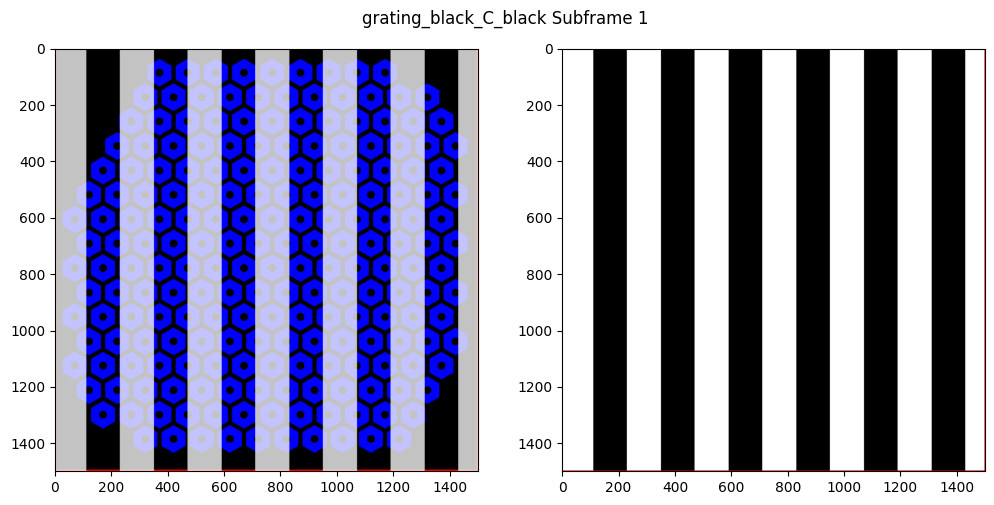

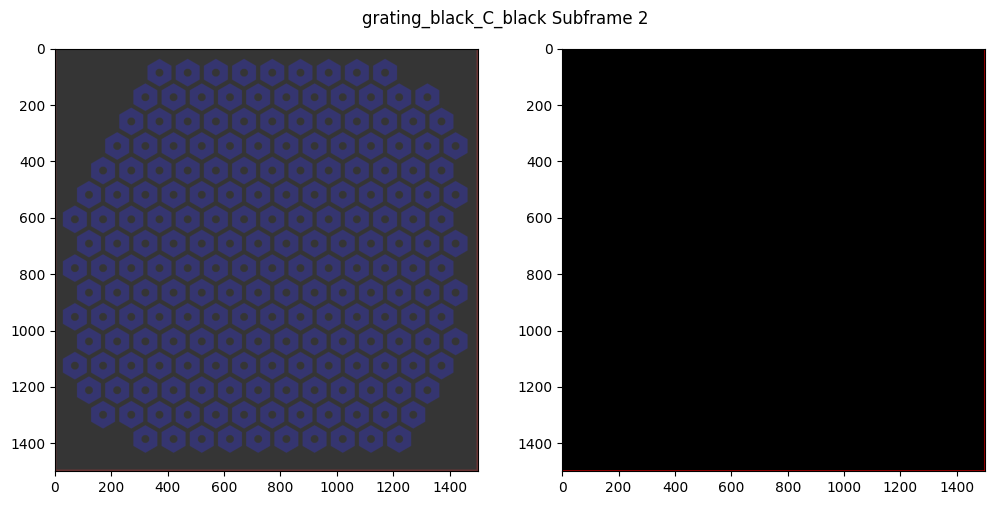

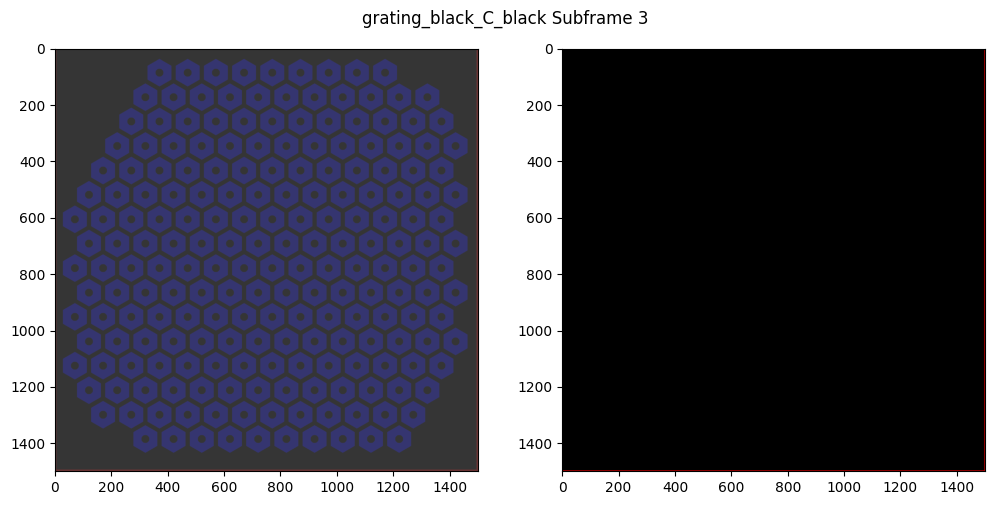

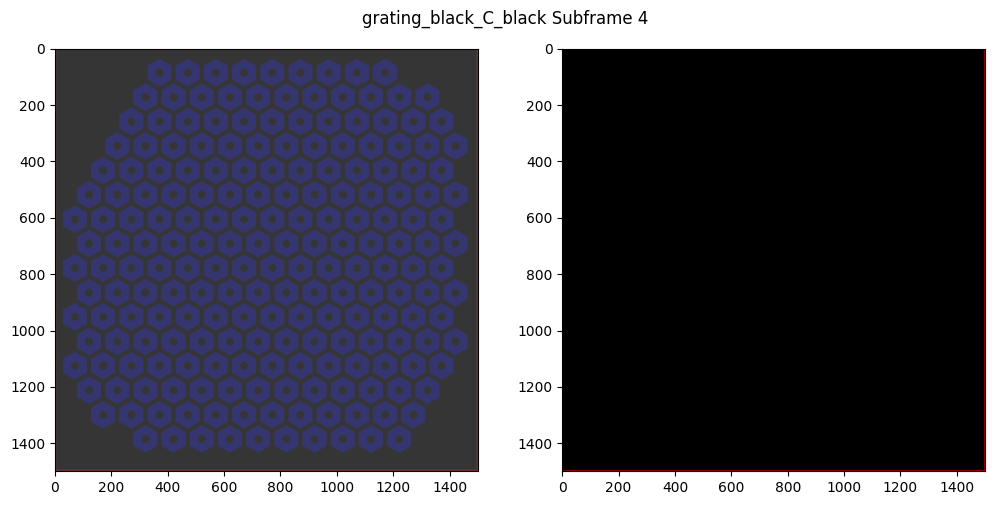

[2024-09-04 11:18:34] INFO       run_rpsim        Running Multiplexing Stage


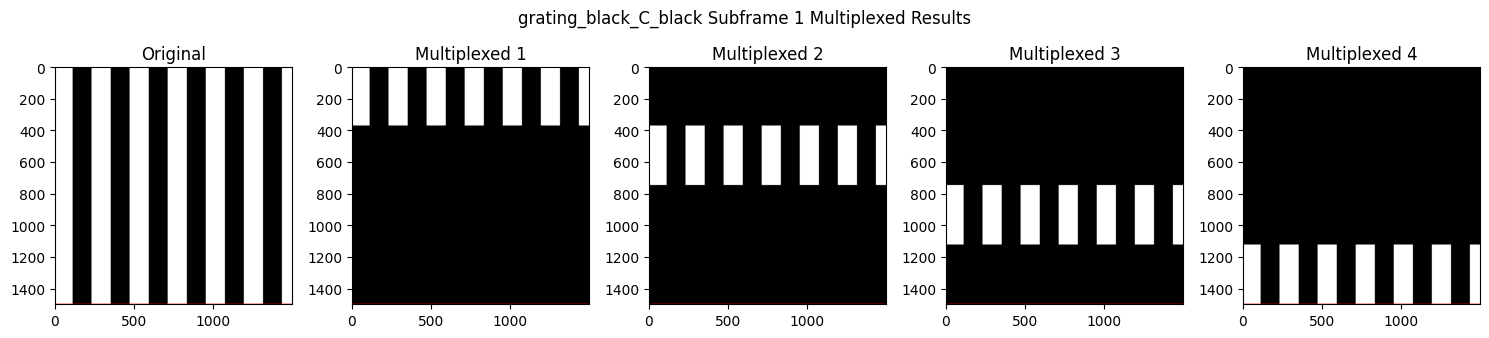

[2024-09-04 11:18:35] INFO       run_rpsim        Running Resistive_Mesh Stage


Is black frame
Is black frame
Is black frame
3.90625
3.90625
3.90625
3.90625


[2024-09-04 11:18:36] INFO       run_rpsim        Running Current_Sequence Stage


Using multiplex list images
Length of frame data: 7
Content of frame data:  [0.9765625, 0.9765625, 0.9765625, 0.9765625, 3.90625, 3.90625, 3.90625]


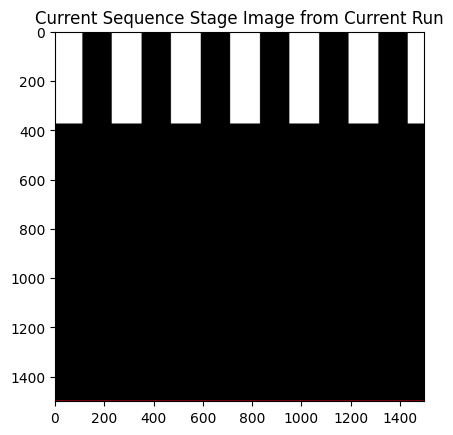

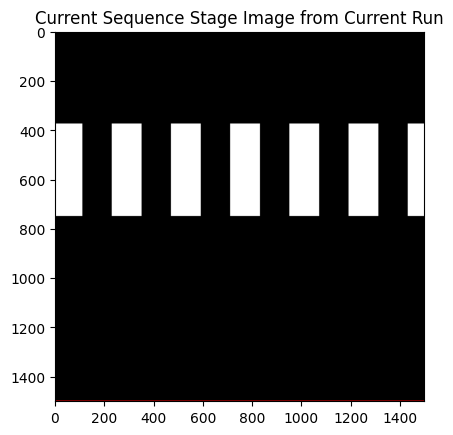

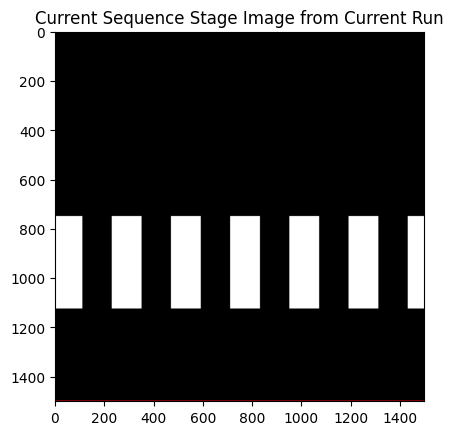

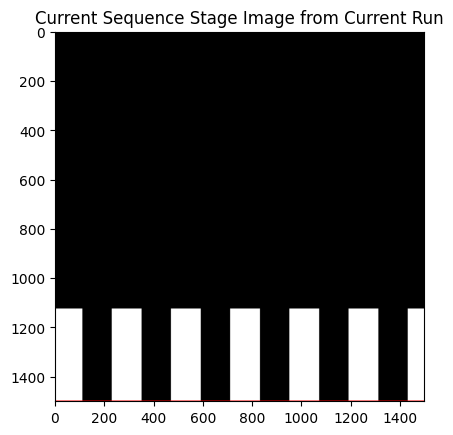

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


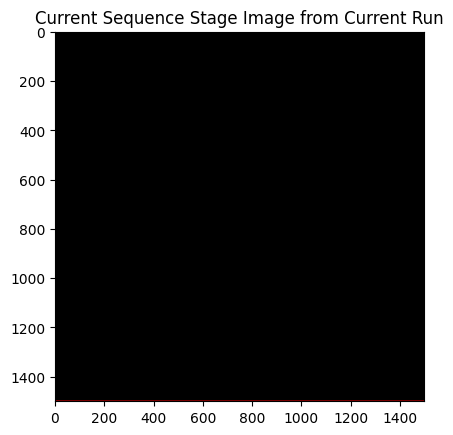

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


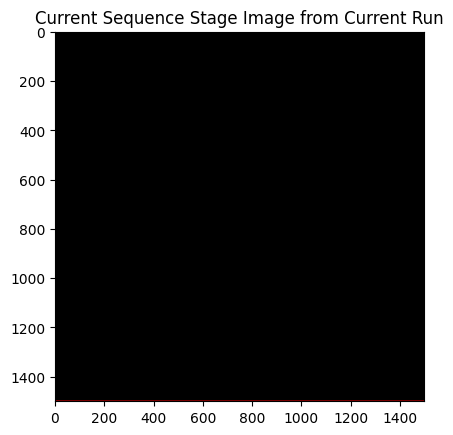

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


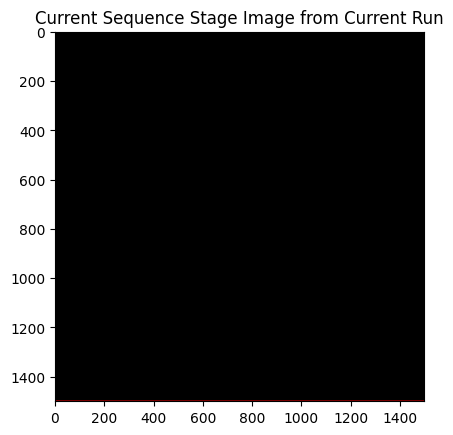

[2024-09-04 11:19:05] INFO       run_rpsim        Running Circuit Stage
[2024-09-04 11:19:06] INFO       run_rpsim        Running Simulation Stage


205


[2024-09-04 11:19:06] ERROR      run_rpsim        [Errno 2] No such file or directory: 'Xyce'
[2024-09-04 11:19:06] ERROR      run_rpsim        Whole error traceback:
 Traceback (most recent call last):
  File "/Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/run_stages/common_run_stage.py", line 60, in run
    self._stage_output = self.run_stage()
  File "/Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/run_stages/simulation_stage.py", line 43, in run_stage
    analysis = simulator.transient(step_time=video_sequence['time_step'] @ U.u_ms,
  File "/opt/miniconda3/lib/python3.9/site-packages/PySpice/Spice/Simulation.py", line 1214, in transient
    return self._run('transient', *args, **kwargs)
  File "/opt/miniconda3/lib/python3.9/site-packages/PySpice/Spice/Xyce/Simulation.py", line 66, in _run
    raw_file = self._xyce_server(spice_input=str(self))
  File "/opt/miniconda3/lib/python3.9/site-packages/PySpice/Spice/Xyce/Server.py", line 123, in __call__
    process = subprocess.Popen(
  

Simulation Stage execution failed with the following error: [Errno 2] No such file or directory: 'Xyce'


In [2]:
### PRIMA CONFIGURATION

configuration = {}

# geometry-defined configuration
configuration["model"]                            = "bipolar"     # model geometry: monopolar or bipolar
configuration["pixel_size"]                       = 100           # pixel size
configuration["pixel_size_suffix"]                = ""         # If large format is required, use "-lg", else use ""
configuration["frame_width"]                      = 1000       # implant radius in mm
configuration["geometry"]                         = "Flat_human"  # geometry settings: HC/Pillar/Flat devices in
# pdish/rat/human
configuration["number_of_diodes"]                 = 2             # number of photo diodes per pixel
configuration["sirof_capacitance"]                = 6             # SIROF capacitance in mF/cm^2
configuration["photosensitive_area_edge_to_edge"] = 92           # edge-to-edge size of the photosensitive area
configuration["active_electrode_radius"]          = 17            # radius of the active electrode in um
configuration["light_to_current_conversion_rate"] = 0.4           # light to current conversion rate in A/W
configuration["photosensitive_area"]              = 4075.72       # total photosensitive area in um^2. Assign "None" for
# auto calculation (only works for monopolar)

# R matrix parameters
configuration["r_matrix_output_file"]             = f'R_{configuration["geometry"]}_PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}.pkl' 
configuration["r_matrix_conductivity"]            = 1             # conductivity scaling factor of the electrolyte

# dynamic simulation configuration
configuration["Ipho_scaling"]                     = 1  # artificial scaling of photo current, useful for
                                                     # parametric sweep (e.g. S-D curve)
configuration["Isat"]                             = 0.02          # diode saturation current in pA
configuration["ideality_factor"]                  = 1.14          # ideality factor n of the diode
configuration["shunt_resistance"]                 = 790150.0     # shunt resistance in Ohm. Assign "None" if no
# shunt
configuration["initial_Vactive"]                  = 0          # Initial bias of the active electrode in V
configuration["temperature"]                      = 37
configuration["nominal_temperature"]              = 25
# TODO make sure that the duration is sufficiently long compared to the frequencz, i.e. at least 6 times the period
configuration["simulation_duration_sec"]          = 1/frequency * 15             # simulation duration in seconds
configuration["simulation_resolution_ms"]         = None          # None defaults to Xyce inner value

# input paths
configuration["user_files_path"]                  = None          # If set to None, defaults to inner user_files directory
configuration["pixel_label_input_file"]           = f'image_sequence/pixel_label_PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}.pkl'

#### Projection sequences related ####

configuration["video_sequence_name"]              = video_sequence_name
configuration["pattern_generation"]               = {"generate_pattern": generate_pattern}

configuration["multiplexing"] = {"multiplex": multiplex, "num_split": 4, "alg": 'horizontal'}
if generate_pattern:
    tmp = \
        {
        "projection_sequences"              : list_projections,
        "font_path"                         : None, # If set to None for, defaults to optometrist font Sloan.otf
        "projection_sequences_stored_config" : None # Used for storing the config, but part of the skipped parameters
        }
    configuration["pattern_generation"].update(tmp)

# define input files for monopolar arrays
configuration["monopolar"] = \
    {
    "return_to_active_area_ratio": 5.7525,              # ratio between return area and total active area 
    "r_matrix_simp_ratio": 0.1,
    "r_matrix_input_file_px_pos": f'r_matrix/COMSOL_results/PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}_pos.csv',
    "r_matrix_input_file_active": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_active.csv',
    "r_matrix_input_file_EP_return_2D": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_EP_return_2D-whole.csv',
    "r_matrix_input_file_diagonal": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_EP_self.csv', # used for resistive mesh only
    "r_matrix_input_file_non_diagonal": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_EP_Rmat.csv' # used for resistive mesh only
    }

# define input files for bipolar arrays
bipolar_dict = \
    {
    "additional_edges": 142,                                     # bipolar only: edge segments of the return
    "r_matrix_simp_ratio": 0.1,
    "r_matrix_input_file_px_pos": f'r_matrix/COMSOL_results/PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}_pos.csv',
    "r_matrix_input_file_active": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_active.csv',
    "r_matrix_input_file_return": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_return.csv',
    "r_matrix_input_file_return_neighbor": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_return_neighbor.csv', # used for resistive mesh only
    }
if configuration["model"] == 'bipolar': # Special file existing only for the bipolar PS100 and PS75 configurations
        bipolar_dict["r_matrix_input_file_return_near"] = f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_return_near.csv'

configuration["bipolar"] = bipolar_dict

# post-process parameters
configuration["post_process"] = \
    {
    "pulse_start_time_in_ms": (1/frequency)*1e3 * 6, # Set to 200 ms if frequency is not defined
    "pulse_duration_in_ms": 9.8,
    # Related to the time dynamics analyzis
    "average_over_pulse_duration": True,
    "pulse_extra_ms": 0,
    "time_averaging_resolution_ms": 1,
    "interpolation_resolution_ms": 1e-3,
    # For improving computations speed, warning it may crash for sume configurations!
    "multiprocessing": False,
    "cpu_to_use": None, # If set to None, automatically uses 2/3 of the cpu available
    # Related to spatial analyzis 
    "depth_values_in_um": None, # if None, defaults to all available in model otherwise use list of list: [[0,1,5,50,155]]
    "on_diode_threshold_mV": 50
    }

configuration["plot_results"] = \
    {
    "plot_time_windwow_start_ms": 200.0, # If set to None, selects the post proces stage values
    "plot_time_window_end_ms": 209.8,
    "plot_potential_depth_um": 60
    }

### EXECUTION
from RPSim import run_rpsim
# Stages name: "pattern_generation" - "resistive_mesh" - "current_sequence" - "circuit" - "simulation" - "post_process" - "plot_results"
run_stages = [ "pattern_generation", "multiplexing", "resistive_mesh", "current_sequence", "circuit", "simulation", 'post_process', 'plot_results']
run_rpsim(configuration=configuration, run_stages=run_stages)#, skip_stages="post_process")

## Bipolar Test 2

In [1]:
import os
import numpy as np
from run_stages.pattern_generation_stage import Text, Grating, Rectangle, Circle, FullField, Subframe, Frame, ProjectionSequence

generate_pattern = True
multiplex = True

intensity = 3
frequency = 64
duration = (1/frequency)*1E3 / 4
grating_width = 120
first_grating = 'grating_black_C_black'
first_subframes= [Subframe(duration_ms=duration, patterns=[Grating(position=(0, 0), rotation=0, unit='um', width_grating=grating_width, pitch_grating=grating_width)]),
            Subframe(duration_ms=duration, patterns=[FullField('black')]),
            Subframe(duration_ms=duration, patterns=[Text(test='A')]),
            Subframe(duration_ms=duration, patterns=[FullField('black')]),
]

frames = [Frame(name=first_grating, repetitions=32, subframes=first_subframes)]
list_projections = [ProjectionSequence(intensity_mW_mm2=intensity, frequency_Hz=frequency, frames=frames)]
video_sequence_name = ['multiplex_bipolar_test_case_2']

[2024-09-04 11:31:17] INFO       run_rpsim        Staring a new run
[2024-09-04 11:31:17] INFO       run_rpsim        Output directory: /Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/user_files/user_output/11_31_17-2024_09_04
[2024-09-04 11:31:17] INFO       run_rpsim        Requested run stages: ['pattern_generation', 'multiplexing', 'resistive_mesh', 'current_sequence', 'circuit', 'simulation', 'post_process', 'plot_results']
[2024-09-04 11:31:17] INFO       run_rpsim        Running the following configuration
====>User Inputs
+--------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------+
| Field                          | Value                                                                                                                                      |
+--------------------------------+------------------------------------------------------------------------------

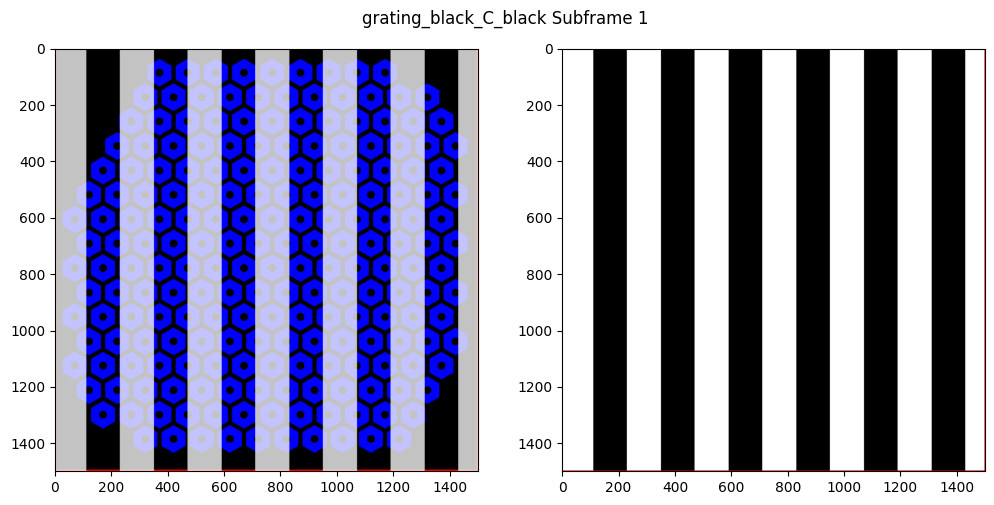

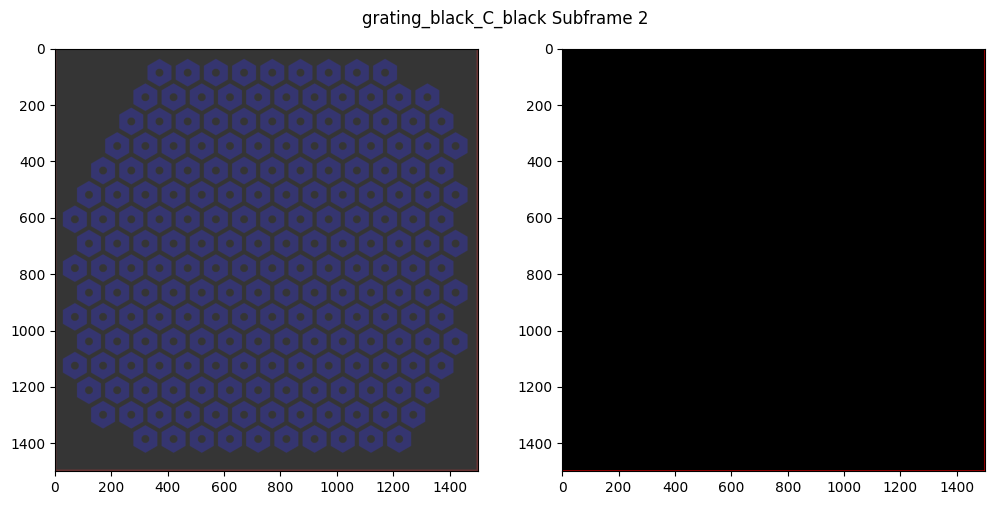

[2024-09-04 11:31:19] ERROR      run_rpsim        not enough values to unpack (expected 2, got 1)
[2024-09-04 11:31:19] ERROR      run_rpsim        Whole error traceback:
 Traceback (most recent call last):
  File "/Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/run_stages/common_run_stage.py", line 60, in run
    self._stage_output = self.run_stage()
  File "/Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/run_stages/pattern_generation_stage.py", line 70, in run_stage
    pattern.draw(drawing_board)
  File "/Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/run_stages/pattern_generation_stage.py", line 662, in draw
    drawing_board.draw_text(self)
  File "/Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/run_stages/pattern_generation_stage.py", line 442, in draw_text
    actual_position = self.convert_user_position_to_image_position(pattern.position, pattern.unit, text_image.size[0], text_image.size[1])
  File "/Users/jiaqiwu/Desktop/Desktop-jq/Retinal/RPSim/run_stages/pattern_generation_s

Pattern_Generation Stage execution failed with the following error: not enough values to unpack (expected 2, got 1)


In [2]:
### PRIMA CONFIGURATION

configuration = {}

# geometry-defined configuration
configuration["model"]                            = "bipolar"     # model geometry: monopolar or bipolar
configuration["pixel_size"]                       = 100           # pixel size
configuration["pixel_size_suffix"]                = ""         # If large format is required, use "-lg", else use ""
configuration["frame_width"]                      = 1000       # implant radius in mm
configuration["geometry"]                         = "Flat_human"  # geometry settings: HC/Pillar/Flat devices in
# pdish/rat/human
configuration["number_of_diodes"]                 = 2             # number of photo diodes per pixel
configuration["sirof_capacitance"]                = 6             # SIROF capacitance in mF/cm^2
configuration["photosensitive_area_edge_to_edge"] = 92           # edge-to-edge size of the photosensitive area
configuration["active_electrode_radius"]          = 17            # radius of the active electrode in um
configuration["light_to_current_conversion_rate"] = 0.4           # light to current conversion rate in A/W
configuration["photosensitive_area"]              = 4075.72       # total photosensitive area in um^2. Assign "None" for
# auto calculation (only works for monopolar)

# R matrix parameters
configuration["r_matrix_output_file"]             = f'R_{configuration["geometry"]}_PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}.pkl' 
configuration["r_matrix_conductivity"]            = 1             # conductivity scaling factor of the electrolyte

# dynamic simulation configuration
configuration["Ipho_scaling"]                     = 1  # artificial scaling of photo current, useful for
                                                     # parametric sweep (e.g. S-D curve)
configuration["Isat"]                             = 0.02          # diode saturation current in pA
configuration["ideality_factor"]                  = 1.14          # ideality factor n of the diode
configuration["shunt_resistance"]                 = 790150.0     # shunt resistance in Ohm. Assign "None" if no
# shunt
configuration["initial_Vactive"]                  = 0          # Initial bias of the active electrode in V
configuration["temperature"]                      = 37
configuration["nominal_temperature"]              = 25
# TODO make sure that the duration is sufficiently long compared to the frequencz, i.e. at least 6 times the period
configuration["simulation_duration_sec"]          = 1/frequency * 15             # simulation duration in seconds
configuration["simulation_resolution_ms"]         = None          # None defaults to Xyce inner value

# input paths
configuration["user_files_path"]                  = None          # If set to None, defaults to inner user_files directory
configuration["pixel_label_input_file"]           = f'image_sequence/pixel_label_PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}.pkl'

#### Projection sequences related ####

configuration["video_sequence_name"]              = video_sequence_name
configuration["pattern_generation"]               = {"generate_pattern": generate_pattern}

configuration["multiplexing"] = {"multiplex": multiplex, "num_split": 4, "alg": 'horizontal'}
if generate_pattern:
    tmp = \
        {
        "projection_sequences"              : list_projections,
        "font_path"                         : None, # If set to None for, defaults to optometrist font Sloan.otf
        "projection_sequences_stored_config" : None # Used for storing the config, but part of the skipped parameters
        }
    configuration["pattern_generation"].update(tmp)

# define input files for monopolar arrays
configuration["monopolar"] = \
    {
    "return_to_active_area_ratio": 5.7525,              # ratio between return area and total active area 
    "r_matrix_simp_ratio": 0.1,
    "r_matrix_input_file_px_pos": f'r_matrix/COMSOL_results/PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}_pos.csv',
    "r_matrix_input_file_active": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_active.csv',
    "r_matrix_input_file_EP_return_2D": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_EP_return_2D-whole.csv',
    "r_matrix_input_file_diagonal": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_EP_self.csv', # used for resistive mesh only
    "r_matrix_input_file_non_diagonal": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_EP_Rmat.csv' # used for resistive mesh only
    }

# define input files for bipolar arrays
bipolar_dict = \
    {
    "additional_edges": 142,                                     # bipolar only: edge segments of the return
    "r_matrix_simp_ratio": 0.1,
    "r_matrix_input_file_px_pos": f'r_matrix/COMSOL_results/PS{configuration["pixel_size"]}{configuration["pixel_size_suffix"]}_pos.csv',
    "r_matrix_input_file_active": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_active.csv',
    "r_matrix_input_file_return": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_return.csv',
    "r_matrix_input_file_return_neighbor": f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_return_neighbor.csv', # used for resistive mesh only
    }
if configuration["model"] == 'bipolar': # Special file existing only for the bipolar PS100 and PS75 configurations
        bipolar_dict["r_matrix_input_file_return_near"] = f'r_matrix/COMSOL_results/{configuration["geometry"]}/{configuration["geometry"]}_PS{configuration["pixel_size"]}_UCD_return_near.csv'

configuration["bipolar"] = bipolar_dict

# post-process parameters
configuration["post_process"] = \
    {
    "pulse_start_time_in_ms": (1/frequency)*1e3 * 6, # Set to 200 ms if frequency is not defined
    "pulse_duration_in_ms": 9.8,
    # Related to the time dynamics analyzis
    "average_over_pulse_duration": True,
    "pulse_extra_ms": 0,
    "time_averaging_resolution_ms": 1,
    "interpolation_resolution_ms": 1e-3,
    # For improving computations speed, warning it may crash for sume configurations!
    "multiprocessing": False,
    "cpu_to_use": None, # If set to None, automatically uses 2/3 of the cpu available
    # Related to spatial analyzis 
    "depth_values_in_um": None, # if None, defaults to all available in model otherwise use list of list: [[0,1,5,50,155]]
    "on_diode_threshold_mV": 50
    }

configuration["plot_results"] = \
    {
    "plot_time_windwow_start_ms": 200.0, # If set to None, selects the post proces stage values
    "plot_time_window_end_ms": 209.8,
    "plot_potential_depth_um": 60
    }

### EXECUTION
from RPSim import run_rpsim
# Stages name: "pattern_generation" - "resistive_mesh" - "current_sequence" - "circuit" - "simulation" - "post_process" - "plot_results"
run_stages = [ "pattern_generation", "multiplexing", "resistive_mesh", "current_sequence", "circuit", "simulation", 'post_process', 'plot_results']
run_rpsim(configuration=configuration, run_stages=run_stages)#, skip_stages="post_process")